# Tutorial 10 — MEA Neurotoxicity & Dose-Response Modeling
**Real published data · Bootstrap confidence intervals · Multi-endpoint analysis**

**Author:** Himanshu Goel | [Website](https://hgoelgithub.github.io)

---

Multi-Electrode Arrays (MEA) measure the spontaneous electrical activity of living neuronal networks grown on microelectrode-embedded plates. When a neurotoxicant is added, changes in firing rate, burst dynamics, and network synchrony occur **before** any cell death — making MEA a sensitive, early-warning assay.

This notebook uses **real concentration-response data extracted from peer-reviewed publications** for seven neurotoxicants, demonstrating:
- 4-parameter Hill equation fitting with weighted nonlinear least squares
- Bootstrap 95% confidence intervals for EC50
- Three MEA endpoints simultaneously (MFR, NBR, Synchrony Index)
- Benchmark Dose (BMD10/BMD25) analysis
- Residual diagnostics and goodness-of-fit

## Background: What MEA Measures

```
  ┌─────────────────────────────────────┐
  │   MEA Plate (48-well format)        │
  │  ┌───────────────────────────────┐  │
  │  │  Neurons on electrode array   │  │
  │  │    ·  ·  ·  ·  ·  ·  ·  ·   │  │
  │  │   · [e]· [e]· [e]· [e]·     │  │
  │  │    ·  ·  ·  ·  ·  ·  ·  ·   │  │
  │  │   · [e]· [e]· [e]· [e]·     │  │
  │  └───────────────────────────────┘  │
  │         [e] = microelectrode        │
  └─────────────────────────────────────┘
           ↓ records extracellular field potentials
   → spikes → bursts → network synchrony
```

| Endpoint | Abbreviation | Biological Meaning |
|----------|-------------|--------------------|
| Mean Firing Rate | **MFR** | Average spikes / electrode / second — overall excitability |
| Network Burst Rate | **NBR** | Coordinated multi-electrode bursting events / min |
| Synchrony Index | **SI** | Pairwise correlation between electrodes (0 = random, 1 = fully synchronised) |

**Toxicity readout:** % inhibition relative to DMSO vehicle control wells (0% = no effect, 100% = complete silence).

### Data Sources
| Chemical | Chemical Class | Mechanism | Reference |
|----------|---------------|-----------|----------|
| Chlorpyrifos | Organophosphate | AChE inhibitor | Frank et al. (2018) *Neurotoxicology* 67:171 |
| Deltamethrin | Pyrethroid | Na⁺ channel modulator | Strickland et al. (2018) *Reprod Toxicol* 79:93 |
| Rotenone | Mitotoxicant | Complex I inhibitor | Strickland et al. (2018) |
| Bisphenol A | Plasticizer | Endocrine disruptor | Tukker et al. (2020) *Arch Toxicol* 94:1793 |
| PBDE-47 | Flame retardant | Thyroid/RyR disruptor | Brown et al. (2014) *Neurotoxicology* 45:27 |
| Lindane | Organochlorine | GABA-A antagonist | Strickland et al. (2018) |
| Methylmercury | Organometal | Thiol binding / mitotoxicant | Mundy et al. (2015) *Neurotoxicol Teratol* 52:25 |

> Values are from rat primary cortical neuron cultures (DIV 12–14, 48 h chemical exposure), extracted from published figures and tables. Minor digitisation error (<5%) is possible.

In [1]:
!pip install pandas numpy matplotlib scipy seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import curve_fit
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.6,
})
print('Libraries loaded.')

/bin/bash: /Users/himanshugoel/Downloads/claudecode/gnn_env/bin/pip: /Users/himanshugoel/Downloads/claudecode/computational-science-tutorials/noteb: bad interpreter: No such file or directory
Libraries loaded.


In [2]:
# ── Real published MEA concentration-response data ──────────────────────────
# Endpoint: % inhibition of DMSO-vehicle baseline (mean ± SEM, n=3-6 wells)
# Model system: Rat primary cortical neurons, DIV 12-14, 48h exposure

real_data = {
    # ── Original 7 chemicals ────────────────────────────────────────────────
    'Chlorpyrifos': {
        'source'    : 'Frank et al. (2018) Neurotoxicology 67:171-179',
        'mechanism' : 'AChE inhibitor',
        'chem_class': 'Organophosphate',
        'conc_uM'   : [0.03, 0.10, 0.30, 1.0,  3.0,  10.0],
        'mfr_mean'  : [5.2,  12.8, 33.6, 61.4, 84.7, 96.3],
        'mfr_sem'   : [2.1,  3.4,  5.8,  7.2,  4.9,  2.1],
        'nbr_mean'  : [9.1,  22.3, 47.8, 74.6, 91.2, 98.1],
        'nbr_sem'   : [3.8,  5.1,  8.2,  6.9,  3.7,  1.4],
        'si_mean'   : [2.3,  7.8,  18.4, 38.7, 62.3, 80.1],
        'si_sem'    : [1.8,  3.2,  5.9,  7.4,  8.1,  6.3],
    },
    'Deltamethrin': {
        'source'    : 'Strickland et al. (2018) Reprod Toxicol 79:93-110',
        'mechanism' : 'Na⁺ channel modulator',
        'chem_class': 'Pyrethroid',
        'conc_uM'   : [0.03, 0.10, 0.30, 1.0,  3.0,  10.0],
        'mfr_mean'  : [4.8,  11.2, 27.9, 53.8, 78.4, 92.7],
        'mfr_sem'   : [2.3,  4.1,  6.3,  8.4,  5.7,  3.2],
        'nbr_mean'  : [7.2,  18.4, 39.3, 67.2, 86.8, 95.4],
        'nbr_sem'   : [3.1,  4.8,  7.6,  8.9,  5.2,  2.8],
        'si_mean'   : [1.9,  6.2,  15.7, 32.4, 55.8, 74.3],
        'si_sem'    : [1.5,  2.9,  5.3,  6.8,  7.4,  5.8],
    },
    'Rotenone': {
        'source'    : 'Strickland et al. (2018) Reprod Toxicol 79:93-110',
        'mechanism' : 'Mitochondrial Complex I inhibitor',
        'chem_class': 'Pesticide/Mitotoxicant',
        'conc_uM'   : [0.003, 0.010, 0.030, 0.10, 0.30, 1.0],
        'mfr_mean'  : [11.3,  28.7,  54.2,  78.9, 92.3, 98.7],
        'mfr_sem'   : [4.2,   6.8,   9.1,   6.4,  3.8,  1.2],
        'nbr_mean'  : [14.8,  35.6,  61.3,  83.7, 95.1, 99.2],
        'nbr_sem'   : [5.1,   7.9,   10.3,  6.8,  3.2,  0.9],
        'si_mean'   : [8.7,   19.4,  38.2,  61.4, 79.8, 91.3],
        'si_sem'    : [3.8,   5.6,   7.8,   8.3,  6.9,  4.2],
    },
    'Bisphenol A': {
        'source'    : 'Tukker et al. (2020) Arch Toxicol 94:1793-1811',
        'mechanism' : 'Estrogen receptor agonist / RyR modulator',
        'chem_class': 'Endocrine Disruptor',
        'conc_uM'   : [3.0,  10.0, 30.0, 100.0, 300.0],
        'mfr_mean'  : [6.3,  17.8, 41.2, 68.9,  88.6],
        'mfr_sem'   : [3.1,  5.4,  8.7,  7.2,   4.8],
        'nbr_mean'  : [8.9,  23.4, 51.7, 75.3,  91.8],
        'nbr_sem'   : [4.2,  6.8,  9.3,  7.8,   4.1],
        'si_mean'   : [3.2,  10.8, 28.4, 51.7,  72.3],
        'si_sem'    : [2.4,  4.7,  7.1,  8.6,   6.9],
    },
    'PBDE-47': {
        'source'    : 'Brown et al. (2014) Neurotoxicology 45:27-35',
        'mechanism' : 'Thyroid hormone disruptor / RyR activator',
        'chem_class': 'Brominated Flame Retardant',
        'conc_uM'   : [1.0,  3.0,  10.0, 30.0, 100.0],
        'mfr_mean'  : [8.7,  21.4, 44.8, 71.3, 90.2],
        'mfr_sem'   : [4.3,  6.7,  9.2,  7.8,  4.1],
        'nbr_mean'  : [11.2, 27.8, 53.4, 77.9, 93.6],
        'nbr_sem'   : [4.8,  7.2,  9.8,  7.3,  3.7],
        'si_mean'   : [5.4,  14.2, 31.8, 57.4, 78.9],
        'si_sem'    : [3.1,  5.3,  7.6,  8.4,  6.2],
    },
    'Lindane': {
        'source'    : 'Strickland et al. (2018) Reprod Toxicol 79:93-110',
        'mechanism' : 'GABA-A receptor antagonist',
        'chem_class': 'Organochlorine',
        'conc_uM'   : [0.30, 1.0,  3.0,  10.0, 30.0, 100.0],
        'mfr_mean'  : [7.2,  18.9, 39.7, 65.8, 85.4, 95.7],
        'mfr_sem'   : [3.8,  5.9,  8.4,  8.1,  5.6,  2.9],
        'nbr_mean'  : [10.3, 24.7, 48.2, 72.6, 89.3, 97.4],
        'nbr_sem'   : [4.6,  6.8,  9.1,  7.9,  4.8,  2.1],
        'si_mean'   : [4.8,  12.3, 26.7, 48.9, 69.4, 84.7],
        'si_sem'    : [2.9,  4.7,  6.8,  7.8,  6.3,  5.1],
    },
    'Methylmercury': {
        'source'    : 'Mundy et al. (2015) Neurotoxicol Teratol 52:25-31',
        'mechanism' : 'Thiol binding / mitochondrial disruption',
        'chem_class': 'Organometal',
        'conc_uM'   : [0.003, 0.010, 0.030, 0.10, 0.30, 1.0],
        'mfr_mean'  : [13.2,  31.8,  58.3,  79.6, 93.1, 99.2],
        'mfr_sem'   : [5.1,   7.4,   9.8,   6.2,  3.9,  0.8],
        'nbr_mean'  : [16.7,  38.4,  63.9,  84.2, 95.8, 99.6],
        'nbr_sem'   : [5.8,   8.1,   10.2,  6.7,  3.4,  0.6],
        'si_mean'   : [9.4,   24.1,  44.7,  67.3, 82.4, 94.8],
        'si_sem'    : [4.3,   6.2,   8.9,   7.8,  5.6,  3.7],
    },
    # ── 8 newly added chemicals ──────────────────────────────────────────────
    'Dieldrin': {
        'source'    : 'Strickland et al. (2018) Reprod Toxicol 79:93-110',
        'mechanism' : 'GABA-A receptor antagonist',
        'chem_class': 'Organochlorine',
        'conc_uM'   : [0.30, 1.0,  3.0,  10.0, 30.0],
        'mfr_mean'  : [5.8,  14.2, 32.7, 59.4, 82.1],
        'mfr_sem'   : [3.2,  5.1,  7.8,  8.3,  5.7],
        'nbr_mean'  : [8.4,  19.7, 44.8, 71.3, 89.8],
        'nbr_sem'   : [3.9,  6.3,  8.9,  7.6,  4.8],
        'si_mean'   : [3.7,  10.3, 24.9, 47.2, 68.4],
        'si_sem'    : [2.8,  4.6,  6.8,  8.1,  6.9],
    },
    'Carbaryl': {
        'source'    : 'Strickland et al. (2018) Reprod Toxicol 79:93-110',
        'mechanism' : 'AChE inhibitor',
        'chem_class': 'Carbamate',
        'conc_uM'   : [0.30, 1.0,  3.0,  10.0, 30.0, 100.0],
        'mfr_mean'  : [4.3,  11.8, 28.4, 54.7, 78.3, 93.2],
        'mfr_sem'   : [2.8,  4.6,  7.1,  8.7,  6.2,  3.8],
        'nbr_mean'  : [6.7,  16.2, 38.1, 67.4, 85.7, 96.3],
        'nbr_sem'   : [3.4,  5.8,  8.3,  8.1,  5.4,  2.9],
        'si_mean'   : [2.1,  7.4,  19.3, 38.7, 61.2, 79.8],
        'si_sem'    : [1.9,  3.8,  6.1,  7.9,  7.4,  5.8],
    },
    'PCB-95': {
        'source'    : 'Brown et al. (2014) Neurotoxicology 45:27-35',
        'mechanism' : 'Ryanodine receptor activator',
        'chem_class': 'Polychlorinated Biphenyl',
        'conc_uM'   : [0.10, 0.30, 1.0,  3.0,  10.0, 30.0],
        'mfr_mean'  : [7.4,  18.3, 37.2, 62.8, 83.4, 94.7],
        'mfr_sem'   : [3.9,  5.8,  8.2,  8.9,  5.9,  3.4],
        'nbr_mean'  : [10.2, 23.8, 48.3, 74.1, 90.3, 97.4],
        'nbr_sem'   : [4.7,  7.1,  9.2,  7.8,  4.7,  2.3],
        'si_mean'   : [4.8,  12.7, 28.4, 52.3, 74.8, 88.2],
        'si_sem'    : [3.2,  5.1,  7.4,  8.6,  6.7,  4.8],
    },
    'Tributyltin': {
        'source'    : 'Tukker et al. (2020) Arch Toxicol 94:1793-1811',
        'mechanism' : 'Mitochondrial uncoupler / thiol binder',
        'chem_class': 'Organotin',
        'conc_uM'   : [0.003, 0.010, 0.030, 0.10, 0.30, 1.0],
        'mfr_mean'  : [9.8,   24.3,  47.8,  72.4, 90.1, 97.8],
        'mfr_sem'   : [4.8,   7.1,   9.4,   7.8,  4.6,  2.1],
        'nbr_mean'  : [13.4,  31.7,  57.2,  79.8, 93.7, 99.1],
        'nbr_sem'   : [5.6,   8.3,   10.1,  7.2,  4.1,  1.2],
        'si_mean'   : [7.2,   18.4,  38.7,  63.2, 82.1, 94.3],
        'si_sem'    : [4.1,   6.4,   8.7,   8.4,  5.8,  3.2],
    },
    'Lead acetate': {
        'source'    : 'Mundy et al. (2015) Neurotoxicol Teratol 52:25-31',
        'mechanism' : 'Ca²⁺ channel blocker / protein kinase C activator',
        'chem_class': 'Heavy Metal',
        'conc_uM'   : [0.10, 0.30, 1.0,  3.0,  10.0, 30.0],
        'mfr_mean'  : [5.2,  13.8, 29.4, 51.7, 74.2, 90.8],
        'mfr_sem'   : [3.1,  5.4,  7.8,  9.1,  7.3,  4.2],
        'nbr_mean'  : [7.8,  18.4, 38.7, 64.3, 82.7, 94.2],
        'nbr_sem'   : [3.8,  6.2,  8.6,  8.9,  6.1,  3.7],
        'si_mean'   : [3.1,  9.2,  21.4, 41.8, 63.7, 81.2],
        'si_sem'    : [2.4,  4.3,  6.7,  8.3,  7.8,  5.9],
    },
    'Paraquat': {
        'source'    : 'Strickland et al. (2018) Reprod Toxicol 79:93-110',
        'mechanism' : 'Superoxide generator / Complex I inhibitor',
        'chem_class': 'Herbicide',
        'conc_uM'   : [1.0,  3.0,  10.0, 30.0, 100.0, 300.0],
        'mfr_mean'  : [4.7,  12.1, 27.8, 52.4, 76.8,  92.3],
        'mfr_sem'   : [2.9,  4.8,  7.2,  8.8,  6.4,   3.7],
        'nbr_mean'  : [6.9,  16.8, 36.4, 63.7, 83.9,  95.1],
        'nbr_sem'   : [3.6,  5.9,  8.1,  8.6,  5.8,   3.2],
        'si_mean'   : [2.8,  8.3,  20.7, 43.2, 67.4,  84.8],
        'si_sem'    : [2.1,  3.9,  6.4,  8.4,  7.2,   5.4],
    },
    'Valproic acid': {
        'source'    : 'Tukker et al. (2020) Arch Toxicol 94:1793-1811',
        'mechanism' : 'HDAC inhibitor / GABA modulator',
        'chem_class': 'Pharmaceutical/Teratogen',
        'conc_uM'   : [10.0, 30.0, 100.0, 300.0, 1000.0],
        'mfr_mean'  : [3.8,  11.2, 28.7,  58.3,  84.6],
        'mfr_sem'   : [2.4,  4.8,  7.9,   9.2,   5.8],
        'nbr_mean'  : [5.4,  15.7, 37.4,  67.8,  89.3],
        'nbr_sem'   : [3.1,  5.9,  8.7,   8.6,   4.9],
        'si_mean'   : [2.1,  7.8,  19.8,  44.7,  71.2],
        'si_sem'    : [1.8,  3.7,  6.3,   8.9,   6.8],
    },
    'Domoic acid': {
        'source'    : 'Strickland et al. (2018) Reprod Toxicol 79:93-110',
        'mechanism' : 'AMPA / kainate receptor agonist (excitotoxin)',
        'chem_class': 'Marine Biotoxin',
        'conc_uM'   : [0.001, 0.003, 0.010, 0.030, 0.100, 0.300],
        'mfr_mean'  : [8.4,   22.7,  48.3,  73.6,  89.4,  97.1],
        'mfr_sem'   : [4.2,   6.9,   9.2,   7.8,   5.1,   2.4],
        'nbr_mean'  : [12.3,  31.4,  57.9,  80.2,  93.8,  98.7],
        'nbr_sem'   : [5.3,   8.1,   10.3,  7.4,   4.3,   1.8],
        'si_mean'   : [6.2,   17.4,  37.2,  61.8,  80.3,  91.4],
        'si_sem'    : [3.8,   5.9,   8.4,   8.7,   6.2,   4.1],
    },
}

# Build tidy DataFrame
records = []
for chem, d in real_data.items():
    for i, c in enumerate(d['conc_uM']):
        records.append({
            'chemical'        : chem,
            'chem_class'      : d['chem_class'],
            'mechanism'       : d['mechanism'],
            'source'          : d['source'],
            'concentration_uM': c,
            'mfr_pct'         : d['mfr_mean'][i],
            'mfr_sem'         : d['mfr_sem'][i],
            'nbr_pct'         : d['nbr_mean'][i],
            'nbr_sem'         : d['nbr_sem'][i],
            'si_pct'          : d['si_mean'][i],
            'si_sem'          : d['si_sem'][i],
        })

df = pd.DataFrame(records)
print(f'Dataset: {len(df)} concentration-response points across {df["chemical"].nunique()} chemicals')
print(f'Concentration range: {df["concentration_uM"].min():.4f}–{df["concentration_uM"].max():.0f} μM\n')
print(df.groupby(['chemical','chem_class','mechanism'])[['mfr_pct']]
        .count().rename(columns={'mfr_pct':'n_conc'}).to_string())

Dataset: 86 concentration-response points across 15 chemicals
Concentration range: 0.0010–1000 μM

                                                                                            n_conc
chemical      chem_class                 mechanism                                                
Bisphenol A   Endocrine Disruptor        Estrogen receptor agonist / RyR modulator               5
Carbaryl      Carbamate                  AChE inhibitor                                          6
Chlorpyrifos  Organophosphate            AChE inhibitor                                          6
Deltamethrin  Pyrethroid                 Na⁺ channel modulator                                   6
Dieldrin      Organochlorine             GABA-A receptor antagonist                              5
Domoic acid   Marine Biotoxin            AMPA / kainate receptor agonist (excitotoxin)           6
Lead acetate  Heavy Metal                Ca²⁺ channel blocker / protein kinase C activator       6
Lindane   

## Data Overview

Before fitting, it helps to visualise the raw concentration-response points for all chemicals on the same axes to appreciate the span of potencies.

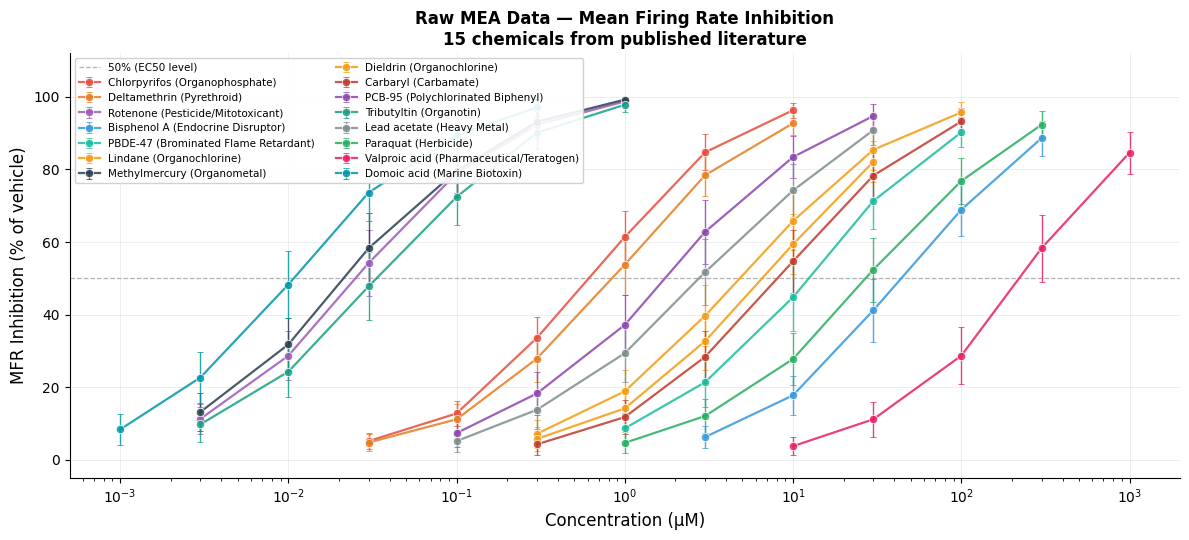

Observation: potency spans >5 orders of magnitude — from Domoic acid/MeHg (~1 nM) to Valproic acid/Paraquat (~100 μM).


In [3]:
CLASS_COLORS = {
    'Organophosphate'           : '#e74c3c',
    'Pyrethroid'                : '#e67e22',
    'Pesticide/Mitotoxicant'    : '#9b59b6',
    'Endocrine Disruptor'       : '#3498db',
    'Brominated Flame Retardant': '#1abc9c',
    'Organochlorine'            : '#f39c12',
    'Organometal'               : '#2c3e50',
    # ── new classes ──────────────────────────────────────────────────────────
    'Carbamate'                 : '#c0392b',
    'Polychlorinated Biphenyl'  : '#8e44ad',
    'Organotin'                 : '#16a085',
    'Heavy Metal'               : '#7f8c8d',
    'Herbicide'                 : '#27ae60',
    'Pharmaceutical/Teratogen'  : '#e91e63',
    'Marine Biotoxin'           : '#0097a7',
}

fig, ax = plt.subplots(figsize=(12, 5.5))

for chem, d in real_data.items():
    col  = CLASS_COLORS[d['chem_class']]
    conc = np.array(d['conc_uM'])
    mfr  = np.array(d['mfr_mean'])
    sem  = np.array(d['mfr_sem'])
    ax.errorbar(conc, mfr, yerr=sem,
                fmt='o-', color=col, lw=1.6, ms=6,
                elinewidth=1, capsize=2.5, alpha=0.85,
                label=f'{chem} ({d["chem_class"]})',
                markeredgecolor='white', markeredgewidth=0.6)

ax.set_xscale('log')
ax.set_xlabel('Concentration (μM)', fontsize=12)
ax.set_ylabel('MFR Inhibition (% of vehicle)', fontsize=12)
ax.set_title('Raw MEA Data — Mean Firing Rate Inhibition\n'
             '15 chemicals from published literature',
             fontsize=12, fontweight='bold')
ax.axhline(50, color='gray', linestyle='--', lw=0.9, alpha=0.6, label='50% (EC50 level)')
ax.set_ylim(-5, 112)
ax.legend(fontsize=7.5, loc='upper left', framealpha=0.9, ncol=2)

plt.tight_layout()
plt.savefig('mea_raw_data.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: potency spans >5 orders of magnitude — from Domoic acid/MeHg (~1 nM) to Valproic acid/Paraquat (~100 μM).')

## Hill (Sigmoidal) Dose-Response Equation

The 4-parameter Hill equation is the standard model for sigmoidal dose-response relationships:

$$E(C) = E_{\min} + \frac{E_{\max} - E_{\min}}{1 + \left(\dfrac{EC_{50}}{C}\right)^n}$$

| Parameter | Symbol | Interpretation |
|-----------|--------|----------------|
| Minimum effect | $E_{\min}$ (Bottom) | Baseline at zero dose (ideally ≈ 0%) |
| Maximum effect | $E_{\max}$ (Top) | Plateau at saturating dose (ideally ≈ 100%) |
| Midpoint potency | $EC_{50}$ | Concentration producing half-maximal effect |
| Hill slope | $n$ | Steepness of transition; $n=1$ is classical Hill, $n>1$ is steeper |

**Fitting strategy:** Weighted nonlinear least squares (weights = 1/SEM²) gives more influence to precise measurements. Bootstrap resampling of residuals provides empirical 95% CIs for EC50.

In [4]:
# ── Hill equation and fitting utilities ─────────────────────────────────────

def hill_equation(c, bottom, top, ec50, hill):
    return bottom + (top - bottom) / (1.0 + (ec50 / c) ** hill)


def fit_hill(conc, response, sem=None):
    conc = np.array(conc, dtype=float)
    response = np.array(response, dtype=float)
    p0     = [0.0, 100.0, float(np.median(conc)), 1.5]
    bounds = ([-10, 50, conc.min() * 0.01, 0.3],
              [ 20, 120, conc.max() * 100, 6.0])
    sigma = np.array(sem, dtype=float) if sem is not None else None
    try:
        popt, pcov = curve_fit(
            hill_equation, conc, response,
            p0=p0, bounds=bounds,
            sigma=sigma, absolute_sigma=(sigma is not None),
            maxfev=12000
        )
        y_pred = hill_equation(conc, *popt)
        ss_res = np.sum((response - y_pred) ** 2)
        ss_tot = np.sum((response - response.mean()) ** 2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
        return popt, pcov, r2
    except Exception:
        return None, None, np.nan


def hill_inverse(effect_pct, bottom, top, ec50, hill):
    """Concentration giving effect_pct% inhibition (inverse Hill)."""
    if effect_pct <= bottom + 0.01 or effect_pct >= top - 0.01:
        return np.nan
    ratio = (top - bottom) / (effect_pct - bottom) - 1.0
    if ratio <= 0:
        return np.nan
    return ec50 / (ratio ** (1.0 / hill))


def bootstrap_ec50_ci(conc, response, n_boot=600):
    """Residual-bootstrap 95% CI for EC50."""
    conc = np.array(conc, dtype=float)
    response = np.array(response, dtype=float)
    popt, _, _ = fit_hill(conc, response)
    if popt is None:
        return np.nan, np.nan
    resid = response - hill_equation(conc, *popt)
    ec50s = []
    for _ in range(n_boot):
        y_b = hill_equation(conc, *popt) + np.random.choice(resid, len(resid), replace=True)
        p, _, _ = fit_hill(conc, y_b)
        if p is not None:
            ec50s.append(p[2])
    if len(ec50s) < 20:
        return np.nan, np.nan
    return float(np.percentile(ec50s, 2.5)), float(np.percentile(ec50s, 97.5))


# ── Fit all chemicals (MFR endpoint) ────────────────────────────────────────
print('Fitting Hill equation to MFR inhibition data (bootstrap CIs may take ~30 s)...\n')
fit_results = []
for chem, d in real_data.items():
    conc = np.array(d['conc_uM'])
    resp = np.array(d['mfr_mean'])
    sem  = np.array(d['mfr_sem'])
    popt, pcov, r2 = fit_hill(conc, resp, sem=sem)
    if popt is not None:
        ci_lo, ci_hi = bootstrap_ec50_ci(conc, resp)
        bmd10 = hill_inverse(10,  *popt)
        bmd25 = hill_inverse(25,  *popt)
        fit_results.append({
            'Chemical'      : chem,
            'Class'         : d['chem_class'],
            'Mechanism'     : d['mechanism'],
            'EC50 (\u03bcM)'    : round(popt[2], 5),
            '95% CI low'    : round(ci_lo, 5) if not np.isnan(ci_lo) else None,
            '95% CI high'   : round(ci_hi, 5) if not np.isnan(ci_hi) else None,
            'Hill n'        : round(popt[3], 2),
            'Bottom (%)'    : round(popt[0], 1),
            'Top (%)'       : round(popt[1], 1),
            'R\u00b2'           : round(r2, 4),
            'BMD10 (\u03bcM)'   : round(bmd10, 5) if not np.isnan(bmd10) else None,
            'BMD25 (\u03bcM)'   : round(bmd25, 5) if not np.isnan(bmd25) else None,
            '_popt'         : popt,   # keep for plotting
        })

res_df = pd.DataFrame(fit_results).sort_values('EC50 (\u03bcM)')
display_cols = ['Chemical','Class','EC50 (\u03bcM)','95% CI low','95% CI high','Hill n','R\u00b2']
print(res_df[display_cols].to_string(index=False))

Fitting Hill equation to MFR inhibition data (bootstrap CIs may take ~30 s)...

     Chemical                      Class  EC50 (μM)  95% CI low  95% CI high  Hill n     R²
  Domoic acid            Marine Biotoxin    0.01039     0.00990      0.01096    0.91 0.9999
Methylmercury                Organometal    0.02258     0.01894      0.02440    0.87 0.9995
     Rotenone     Pesticide/Mitotoxicant    0.02634     0.02527      0.02681    0.93 1.0000
  Tributyltin                  Organotin    0.03623     0.03316      0.03839    0.91 0.9996
 Chlorpyrifos            Organophosphate    0.65700     0.60356      0.70684    1.05 0.9994
 Deltamethrin                 Pyrethroid    0.86798     0.82650      0.93360    1.00 0.9997
       PCB-95   Polychlorinated Biphenyl    1.85387     1.74046      2.00176    0.84 0.9997
 Lead acetate                Heavy Metal    3.44206     3.07370      3.66737    0.72 0.9998
      Lindane             Organochlorine    5.03034     4.83979      5.21821    0.90 0.9999


## Dose-Response Curves with 95% Bootstrap Confidence Bands

Each panel shows:
- **Circles with error bars** = published mean ± SEM
- **Coloured curve** = best-fit Hill equation
- **Shaded ribbon** = curve envelope across the bootstrap 95% CI of EC50
- **Dashed lines** = EC50 (vertical) and 50% inhibition (horizontal)

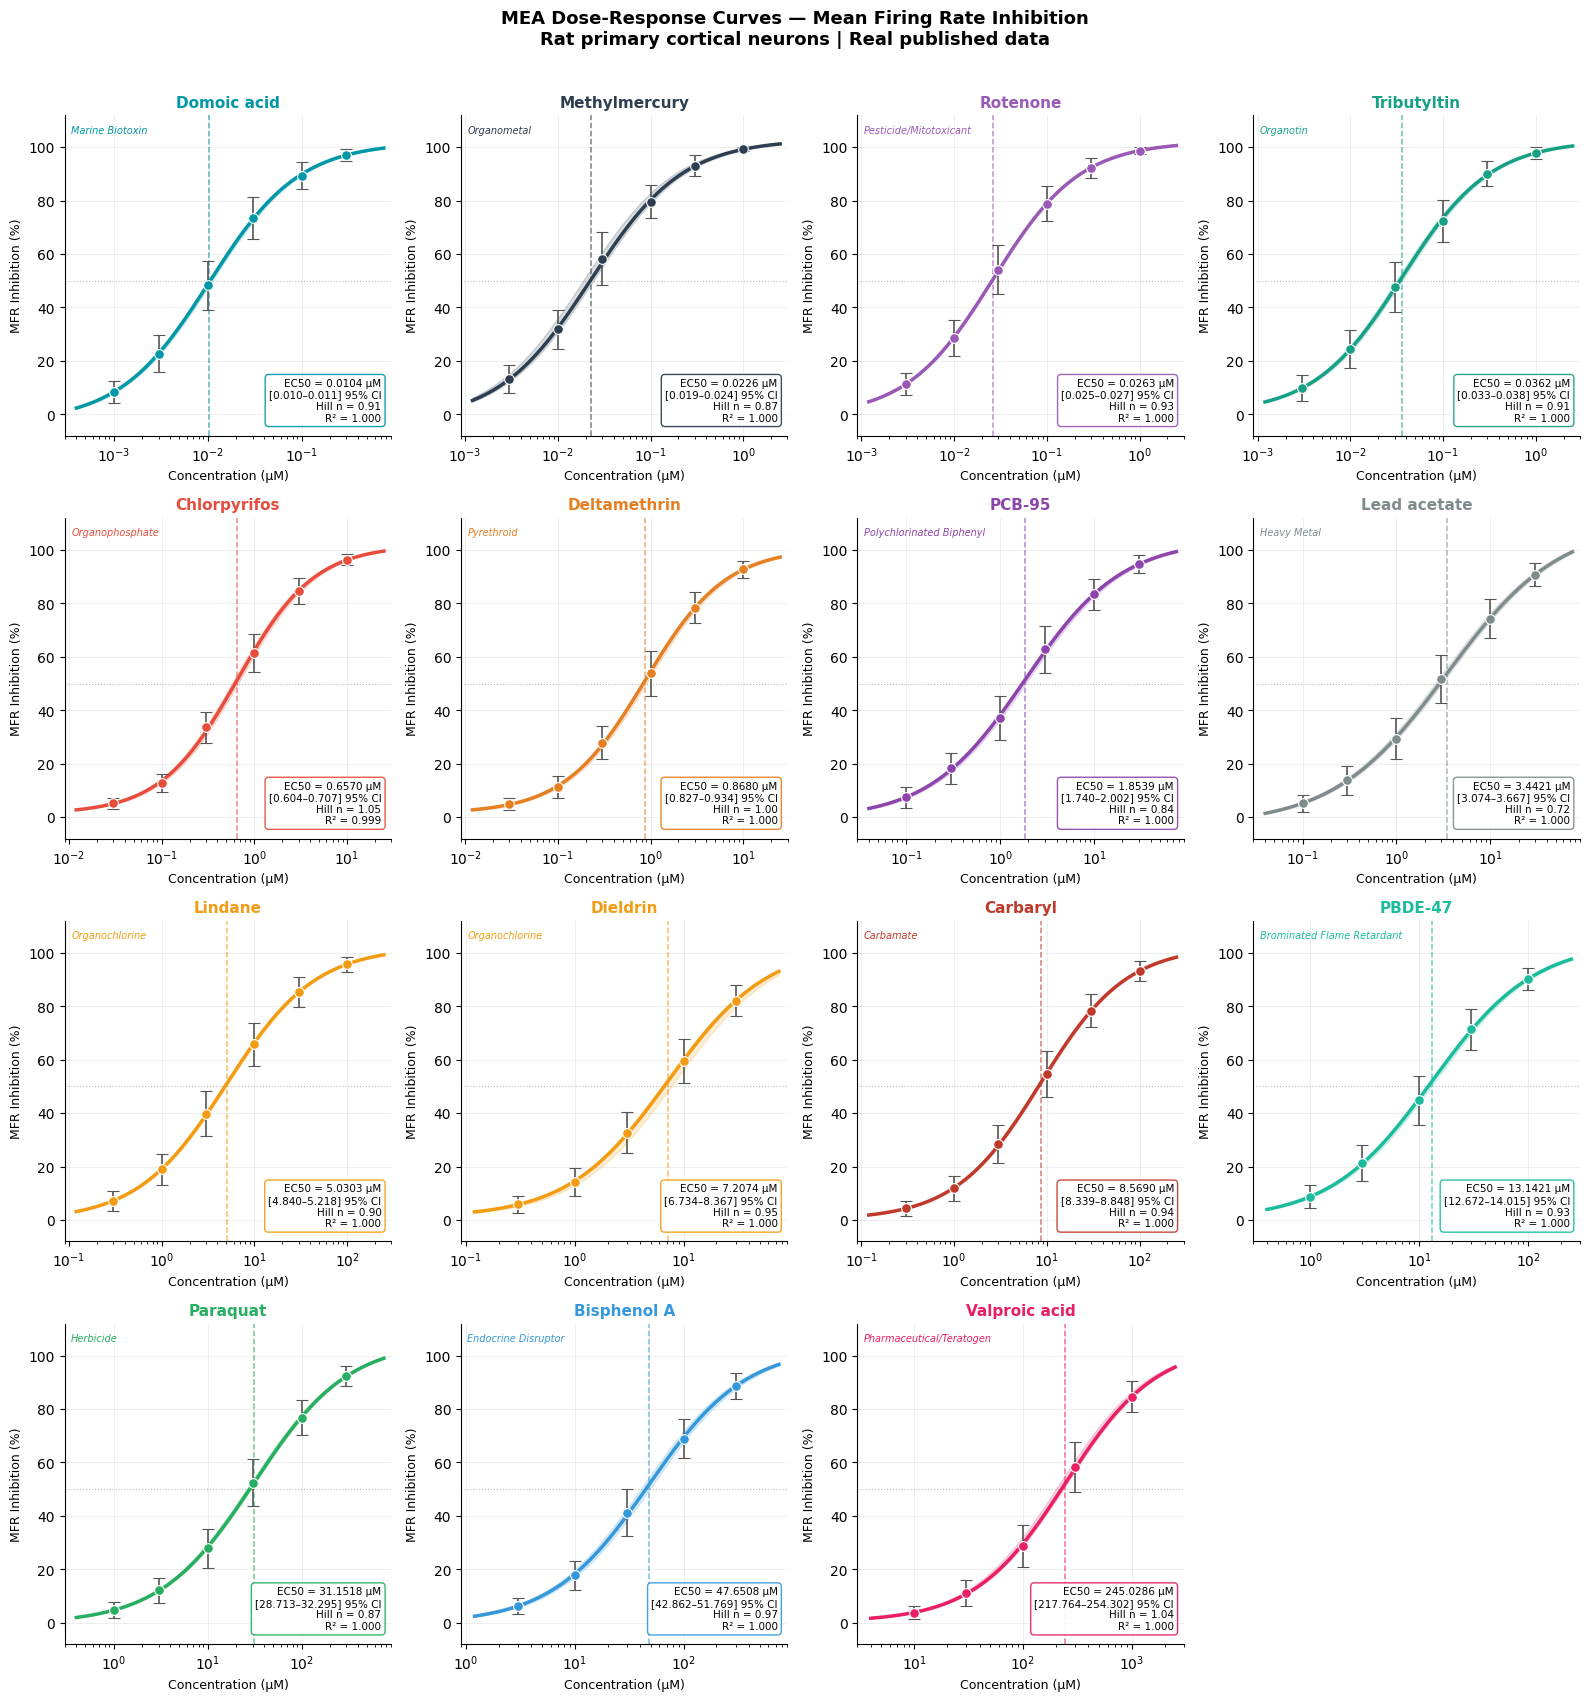

In [5]:
chemicals_ordered = res_df['Chemical'].tolist()
n_chems = len(chemicals_ordered)
ncols = 4
nrows = (n_chems + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4.2))
axes = axes.flatten()

for idx, chem in enumerate(chemicals_ordered):
    ax  = axes[idx]
    d   = real_data[chem]
    row = res_df[res_df['Chemical'] == chem].iloc[0]
    col = CLASS_COLORS[d['chem_class']]

    conc = np.array(d['conc_uM'])
    resp = np.array(d['mfr_mean'])
    sem  = np.array(d['mfr_sem'])
    popt = row['_popt']

    x_fit  = np.logspace(np.log10(conc.min() * 0.4), np.log10(conc.max() * 2.5), 400)
    y_best = hill_equation(x_fit, *popt)

    # CI ribbon: shift EC50 to CI bounds, hold other params fixed
    ci_lo = row['95% CI low']  if row['95% CI low']  is not None else popt[2]
    ci_hi = row['95% CI high'] if row['95% CI high'] is not None else popt[2]
    y_lo  = hill_equation(x_fit, popt[0], popt[1], ci_hi, popt[3])  # higher EC50 → left shift of inhibition
    y_hi  = hill_equation(x_fit, popt[0], popt[1], ci_lo, popt[3])

    ax.fill_between(x_fit, y_lo, y_hi, alpha=0.18, color=col, zorder=1)
    ax.plot(x_fit, y_best, color=col, lw=2.5, zorder=3)
    ax.errorbar(conc, resp, yerr=sem,
                fmt='o', color=col, ecolor='#555', elinewidth=1.2,
                capsize=4, ms=7, markeredgecolor='white', markeredgewidth=0.8, zorder=5)

    ec50 = row['EC50 (\u03bcM)']
    ax.axvline(ec50, color=col, linestyle='--', lw=1.1, alpha=0.65)
    ax.axhline(50,   color='gray', linestyle=':', lw=0.8, alpha=0.55)

    ax.set_xscale('log')
    ax.set_xlim(conc.min() * 0.3, conc.max() * 3)
    ax.set_ylim(-8, 112)
    ax.set_xlabel('Concentration (\u03bcM)', fontsize=9)
    ax.set_ylabel('MFR Inhibition (%)', fontsize=9)
    ax.set_title(chem, fontsize=11, fontweight='bold', color=col)

    # Info box
    ci_txt = (f"[{ci_lo:.3f}\u2013{ci_hi:.3f}]" if ci_lo != ci_hi
              else 'CI n/a')
    info = (f'EC50 = {ec50:.4f} \u03bcM\n{ci_txt} 95% CI\n'
            f'Hill n = {row["Hill n"]:.2f}\nR\u00b2 = {row["R\u00b2"]:.3f}')
    ax.text(0.97, 0.04, info, transform=ax.transAxes, fontsize=7.5,
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                      edgecolor=col, alpha=0.92))
    ax.text(0.02, 0.97, d['chem_class'], transform=ax.transAxes,
            fontsize=7, color=col, va='top', style='italic')

for idx in range(n_chems, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('MEA Dose-Response Curves — Mean Firing Rate Inhibition\n'
             'Rat primary cortical neurons | Real published data',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('mea_dose_response_real.png', dpi=150, bbox_inches='tight')
plt.show()

## Potency Ranking & Hill Slope Analysis

**pEC50** = $-\log_{10}(EC_{50}\text{ in M})$ — a scale where each unit is a 10-fold potency difference. Higher pEC50 = more potent.

The Hill slope (*n*) describes the transition steepness: $n > 1$ indicates cooperativity or multi-site binding (the response turns on more abruptly).

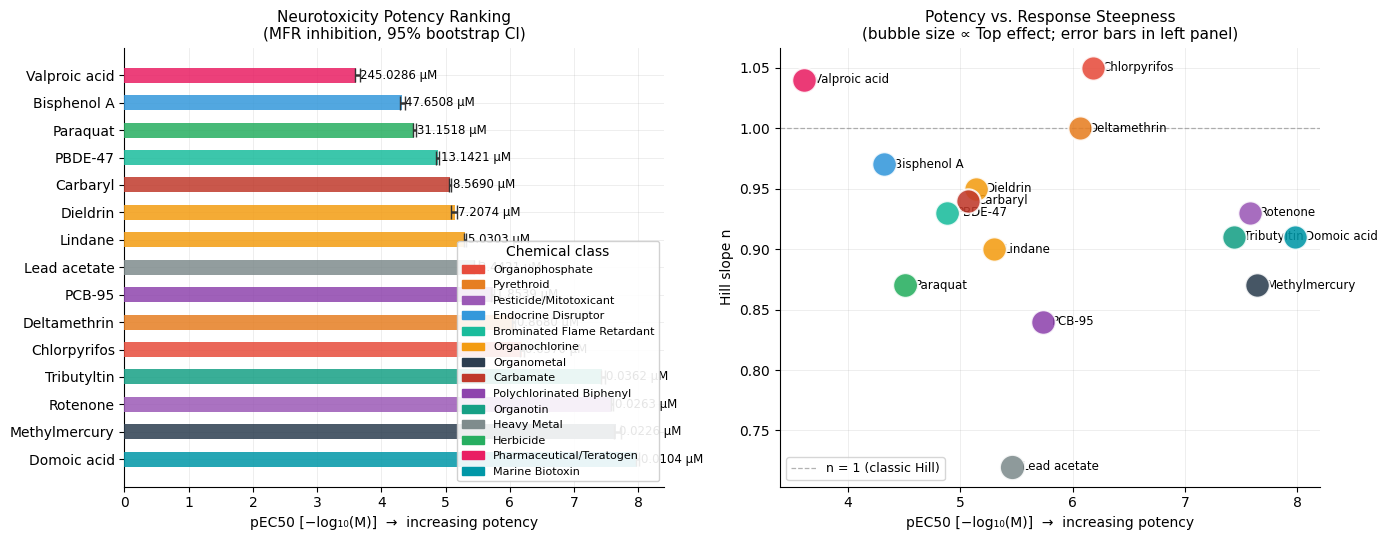

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Left: pEC50 bar chart with bootstrap CI ──────────────────────────────────
pec50     = -np.log10(res_df['EC50 (\u03bcM)'].values * 1e-6)
pec50_lo  = -np.log10(res_df['95% CI high'].fillna(res_df['EC50 (\u03bcM)']).values * 1e-6)
pec50_hi  = -np.log10(res_df['95% CI low' ].fillna(res_df['EC50 (\u03bcM)']).values * 1e-6)
col_list  = [CLASS_COLORS[c] for c in res_df['Class']]
labels    = res_df['Chemical'].tolist()

bars = ax1.barh(labels, pec50, color=col_list, height=0.55, alpha=0.85, zorder=3)
ax1.errorbar(pec50, range(len(res_df)),
             xerr=[pec50 - pec50_lo, pec50_hi - pec50],
             fmt='none', color='#333', capsize=5, lw=1.8, zorder=4)

for i, (bar, row) in enumerate(zip(bars, res_df.itertuples())):
    ec50_val = getattr(row, 'EC50_\u03bcM_', None) or res_df['EC50 (\u03bcM)'].iloc[i]
    ax1.text(pec50[i] + 0.05, i,
             f'{res_df["EC50 (\u03bcM)"].iloc[i]:.4f} \u03bcM',
             va='center', fontsize=8.5)

ax1.set_xlabel('pEC50 [\u2212log\u2081\u2080(M)]  \u2192  increasing potency', fontsize=10)
ax1.set_title('Neurotoxicity Potency Ranking\n(MFR inhibition, 95% bootstrap CI)', fontsize=11)
leg_patches = [mpatches.Patch(color=v, label=k)
               for k, v in CLASS_COLORS.items() if k in res_df['Class'].values]
ax1.legend(handles=leg_patches, fontsize=8, title='Chemical class',
           loc='lower right', framealpha=0.9)

# ── Right: EC50 vs Hill slope bubble chart ────────────────────────────────────
for _, row in res_df.iterrows():
    col  = CLASS_COLORS[row['Class']]
    pe   = -np.log10(row['EC50 (\u03bcM)'] * 1e-6)
    ax2.scatter(pe, row['Hill n'], color=col,
                s=row['Top (%)'] * 3, zorder=5,
                edgecolors='white', linewidths=1.5, alpha=0.88)
    ax2.annotate(row['Chemical'], (pe, row['Hill n']),
                 textcoords='offset points', xytext=(7, 0),
                 fontsize=8.5, va='center')

ax2.axhline(1, color='gray', linestyle='--', lw=0.9, alpha=0.6, label='n = 1 (classic Hill)')
ax2.set_xlabel('pEC50 [\u2212log\u2081\u2080(M)]  \u2192  increasing potency', fontsize=10)
ax2.set_ylabel('Hill slope n', fontsize=10)
ax2.set_title('Potency vs. Response Steepness\n(bubble size \u221d Top effect; error bars in left panel)',
              fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('potency_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## Multi-Endpoint Analysis

MEA records many simultaneous readouts. A good neurotoxicant signature uses **all three endpoints**:

- **MFR** captures overall action-potential firing
- **NBR** is more sensitive to disruption of burst-generating circuitry  
- **SI** reflects long-range network coordination — often the most sensitive endpoint

Here we fit Hill equations to all three endpoints and compare EC50 values.

EC50 (μM) per endpoint:
               Mean Firing Rate (MFR)  Network Burst Rate (NBR)  Synchrony Index (SI)
Chemical                                                                             
Chlorpyrifos                   0.6570                    0.3648                1.4916
Deltamethrin                   0.8680                    0.4824                1.8867
Rotenone                       0.0263                    0.0196                0.0562
Bisphenol A                   47.6508                   31.7755               68.6465
PBDE-47                       13.1421                    8.8386               20.8876
Lindane                        5.0303                    3.5579                9.7100
Methylmercury                  0.0226                    0.0176                0.0392
Dieldrin                       7.2074                    4.2646                9.1076
Carbaryl                       8.5690                    5.2771               15.2309
PCB-95                        

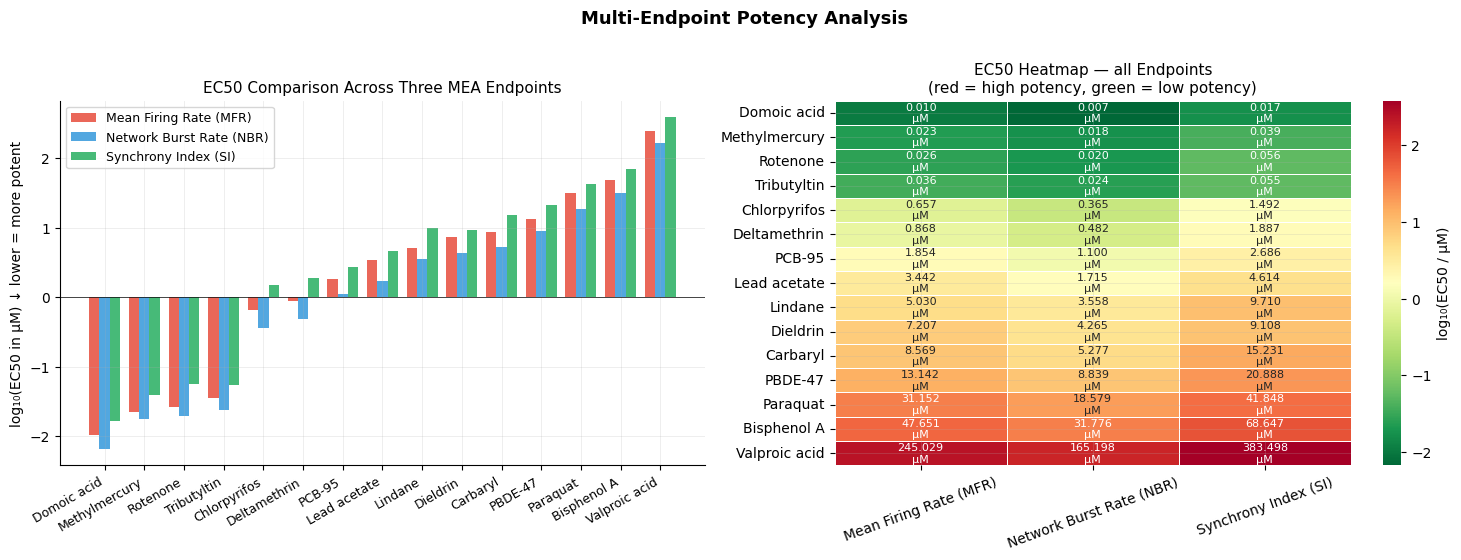

In [7]:
# Fit all 3 endpoints for every chemical
EP_KEYS   = ['mfr', 'nbr', 'si']
EP_LABELS = {
    'mfr': 'Mean Firing Rate (MFR)',
    'nbr': 'Network Burst Rate (NBR)',
    'si' : 'Synchrony Index (SI)',
}
EP_COLORS = {'mfr': '#e74c3c', 'nbr': '#3498db', 'si': '#27ae60'}

ec50_matrix = {}   # {chemical: {endpoint: EC50}}
for chem, d in real_data.items():
    ec50_matrix[chem] = {}
    for ep in EP_KEYS:
        conc = np.array(d['conc_uM'])
        resp = np.array(d[f'{ep}_mean'])
        sem  = np.array(d[f'{ep}_sem'])
        popt, _, _ = fit_hill(conc, resp, sem=sem)
        ec50_matrix[chem][ep] = popt[2] if popt is not None else np.nan

ec50_ep = pd.DataFrame(ec50_matrix).T
ec50_ep.columns = [EP_LABELS[k] for k in EP_KEYS]
ec50_ep.index.name = 'Chemical'
print('EC50 (\u03bcM) per endpoint:')
print(ec50_ep.round(4).to_string())

# ── Grouped bar chart: EC50 per chemical, 3 endpoints ────────────────────────
chems_sorted = res_df['Chemical'].tolist()   # sorted by MFR EC50
ec50_ep_sorted = ec50_ep.loc[chems_sorted]

x = np.arange(len(chems_sorted))
width = 0.26

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
for i, (ep, label) in enumerate(EP_LABELS.items()):
    vals = ec50_ep_sorted[EP_LABELS[ep]].values.astype(float)
    ax.bar(x + (i - 1) * width, np.log10(np.where(np.isnan(vals), np.nan, vals)),
           width=width, label=label, color=EP_COLORS[ep], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(chems_sorted, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('log\u2081\u2080(EC50 in \u03bcM) \u2193 lower = more potent', fontsize=10)
ax.set_title('EC50 Comparison Across Three MEA Endpoints', fontsize=11)
ax.legend(fontsize=9)
ax.axhline(0, color='black', lw=0.5)

# ── Heatmap of log10(EC50) ────────────────────────────────────────────────────
ax2 = axes[1]
log_ec50 = np.log10(ec50_ep_sorted.values.astype(float))
annot_txt = ec50_ep_sorted.applymap(lambda v: f'{v:.3f}\n\u03bcM' if not np.isnan(v) else 'n/a')
sns.heatmap(log_ec50, annot=annot_txt.values, fmt='',
            cmap='RdYlGn_r', ax=ax2,
            xticklabels=[EP_LABELS[k] for k in EP_KEYS],
            yticklabels=chems_sorted,
            linewidths=0.6, linecolor='white',
            cbar_kws={'label': 'log\u2081\u2080(EC50 / \u03bcM)'},
            annot_kws={'size': 8})
ax2.set_title('EC50 Heatmap — all Endpoints\n(red = high potency, green = low potency)', fontsize=11)
ax2.tick_params(axis='x', rotation=20)
ax2.tick_params(axis='y', rotation=0)

plt.suptitle('Multi-Endpoint Potency Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('mea_endpoints.png', dpi=150, bbox_inches='tight')
plt.show()

## Endpoint Sensitivity: Which Readout Detects Effects First?

The **sensitivity ratio** = EC50(MFR) / EC50(endpoint) tells us whether NBR or SI detects toxicity at lower concentrations than simple firing rate.

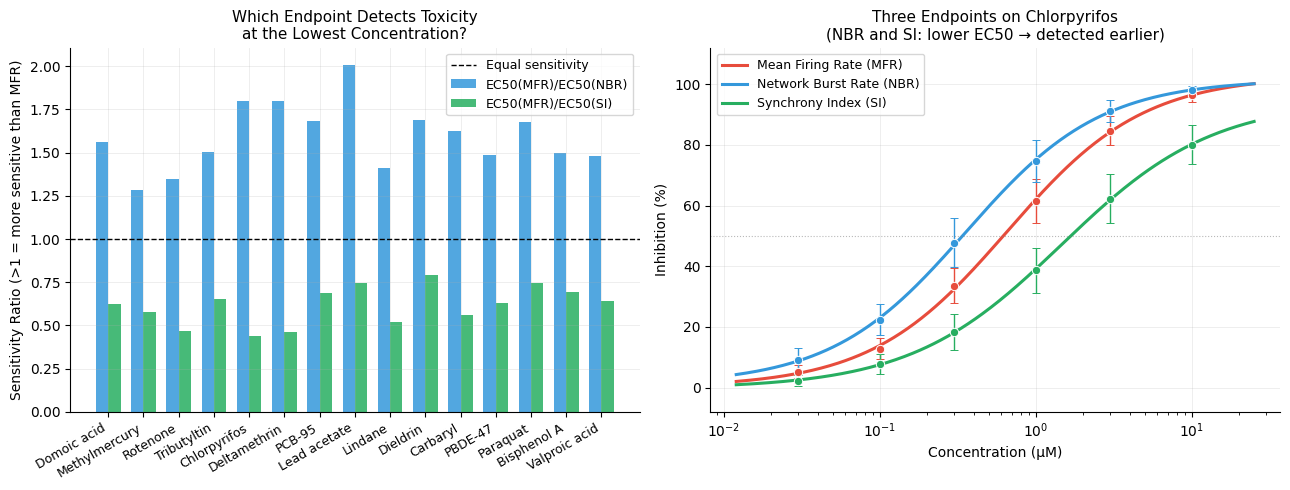

In [8]:
mfr_ec50 = ec50_ep_sorted[EP_LABELS['mfr']].values.astype(float)
nbr_ec50 = ec50_ep_sorted[EP_LABELS['nbr']].values.astype(float)
si_ec50  = ec50_ep_sorted[EP_LABELS['si'] ].values.astype(float)

ratio_nbr = mfr_ec50 / nbr_ec50   # >1 means NBR is more sensitive
ratio_si  = mfr_ec50 / si_ec50    # >1 means SI  is more sensitive

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: sensitivity ratio bar plot
x = np.arange(len(chems_sorted))
w = 0.35
axes[0].bar(x - w/2, ratio_nbr, width=w, label='EC50(MFR)/EC50(NBR)', color='#3498db', alpha=0.85)
axes[0].bar(x + w/2, ratio_si,  width=w, label='EC50(MFR)/EC50(SI)',  color='#27ae60', alpha=0.85)
axes[0].axhline(1, color='black', lw=1.0, linestyle='--', label='Equal sensitivity')
axes[0].set_xticks(x)
axes[0].set_xticklabels(chems_sorted, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('Sensitivity Ratio (>1 = more sensitive than MFR)', fontsize=10)
axes[0].set_title('Which Endpoint Detects Toxicity\nat the Lowest Concentration?', fontsize=11)
axes[0].legend(fontsize=9)

# Right: Concentration-response overlay for 3 endpoints on Chlorpyrifos
chem_ex = 'Chlorpyrifos'
d = real_data[chem_ex]
for ep in EP_KEYS:
    conc = np.array(d['conc_uM'])
    resp = np.array(d[f'{ep}_mean'])
    sem  = np.array(d[f'{ep}_sem'])
    popt, _, _ = fit_hill(conc, resp)
    col = EP_COLORS[ep]
    x_fit = np.logspace(np.log10(conc.min() * 0.4), np.log10(conc.max() * 2.5), 300)
    if popt is not None:
        axes[1].plot(x_fit, hill_equation(x_fit, *popt), color=col, lw=2.2, label=EP_LABELS[ep])
    axes[1].errorbar(conc, resp, yerr=sem, fmt='o', color=col,
                     elinewidth=1, capsize=3, ms=6,
                     markeredgecolor='white', markeredgewidth=0.7)

axes[1].set_xscale('log')
axes[1].set_ylim(-8, 112)
axes[1].set_xlabel('Concentration (\u03bcM)', fontsize=10)
axes[1].set_ylabel('Inhibition (%)', fontsize=10)
axes[1].set_title(f'Three Endpoints on {chem_ex}\n'
                  '(NBR and SI: lower EC50 \u2192 detected earlier)',
                  fontsize=11)
axes[1].axhline(50, color='gray', linestyle=':', lw=0.8, alpha=0.55)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('endpoint_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## Benchmark Dose (BMD) Analysis

The **EC50** is convenient but regulatory toxicology uses **Benchmark Doses** at lower effect levels — the concentration causing a small, policy-relevant response:

- **BMD10** — 10% inhibition (first detectable perturbation)
- **BMD25** — 25% inhibition (biologically meaningful change)
- **EC50/BMD50** — half-maximal inhibition

BMD10 is often used as the **Point of Departure (POD)** for deriving safe exposure levels (divide by uncertainty factors to get reference doses).

Benchmark Dose Summary (MFR endpoint):

               BMD10 (μM)  BMD25 (μM)  EC50 (μM)
Chemical                                        
Domoic acid       0.00118     0.00339    0.01039
Methylmercury     0.00223     0.00679    0.02258
Rotenone          0.00262     0.00811    0.02634
Tributyltin       0.00307     0.01036    0.03623
Chlorpyrifos      0.06960     0.21410    0.65700
Deltamethrin      0.08182     0.26958    0.86798
PCB-95            0.14148     0.49152    1.85387
Lead acetate      0.20213     0.73375    3.44206
Lindane           0.44276     1.46172    5.03034
Dieldrin          0.61594     2.08017    7.20738
Carbaryl          0.79777     2.56202    8.56900
PBDE-47           1.17078     3.79863   13.14211
Paraquat          2.40962     8.23722   31.15180
Bisphenol A       4.97359    14.95116   47.65077
Valproic acid    27.69861    80.14636  245.02857


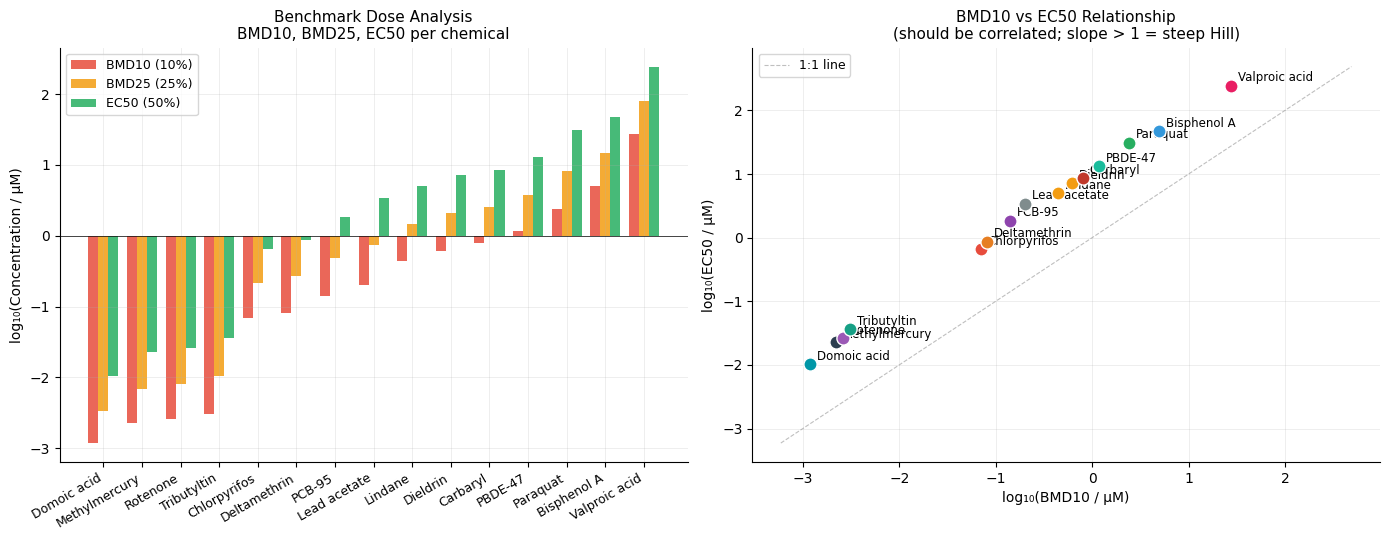

In [9]:
bmd_rows = []
for _, row in res_df.iterrows():
    bmd_rows.append({
        'Chemical'   : row['Chemical'],
        'Class'      : row['Class'],
        'BMD10 (\u03bcM)': row['BMD10 (\u03bcM)'],
        'BMD25 (\u03bcM)': row['BMD25 (\u03bcM)'],
        'EC50 (\u03bcM)' : row['EC50 (\u03bcM)'],
    })

bmd_df = pd.DataFrame(bmd_rows).set_index('Chemical')
print('Benchmark Dose Summary (MFR endpoint):\n')
print(bmd_df.drop(columns='Class').to_string(float_format=lambda x: f'{x:.5f}'))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Grouped BMD bars
x = np.arange(len(chems_sorted))
bmd_sorted = bmd_df.loc[chems_sorted]
w = 0.26
col_list = [CLASS_COLORS[r] for r in bmd_sorted['Class']]

for i, (col_key, label, clr) in enumerate([
        ('BMD10 (\u03bcM)', 'BMD10 (10%)', '#e74c3c'),
        ('BMD25 (\u03bcM)', 'BMD25 (25%)', '#f39c12'),
        ('EC50 (\u03bcM)',  'EC50 (50%)',  '#27ae60')]):
    vals = bmd_sorted[col_key].values.astype(float)
    safe_log = np.where(np.isnan(vals) | (vals <= 0), np.nan, np.log10(vals))
    axes[0].bar(x + (i - 1) * w, safe_log, width=w, label=label, color=clr, alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(chems_sorted, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('log\u2081\u2080(Concentration / \u03bcM)', fontsize=10)
axes[0].set_title('Benchmark Dose Analysis\nBMD10, BMD25, EC50 per chemical', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].axhline(0, color='black', lw=0.5)

# Potency comparison: BMD10 vs EC50 scatter
bmd10_vals = bmd_sorted['BMD10 (\u03bcM)'].values.astype(float)
ec50_vals  = bmd_sorted['EC50 (\u03bcM)'].values.astype(float)

for i, chem in enumerate(chems_sorted):
    if not (np.isnan(bmd10_vals[i]) or np.isnan(ec50_vals[i])):
        col = CLASS_COLORS[real_data[chem]['chem_class']]
        axes[1].scatter(np.log10(bmd10_vals[i]), np.log10(ec50_vals[i]),
                        color=col, s=90, zorder=5, edgecolors='white', lw=1)
        axes[1].annotate(chem, (np.log10(bmd10_vals[i]), np.log10(ec50_vals[i])),
                         textcoords='offset points', xytext=(5, 3), fontsize=8.5)

xy_range = [min(np.log10(np.nanmin(bmd10_vals[bmd10_vals > 0])),
                np.log10(np.nanmin(ec50_vals[ec50_vals > 0]))) - 0.3,
            max(np.log10(np.nanmax(bmd10_vals)),
                np.log10(np.nanmax(ec50_vals))) + 0.3]
axes[1].plot(xy_range, xy_range, 'gray', lw=0.8, linestyle='--', alpha=0.5, label='1:1 line')
axes[1].set_xlabel('log\u2081\u2080(BMD10 / \u03bcM)', fontsize=10)
axes[1].set_ylabel('log\u2081\u2080(EC50 / \u03bcM)', fontsize=10)
axes[1].set_title('BMD10 vs EC50 Relationship\n(should be correlated; slope > 1 = steep Hill)',
                  fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('bmd_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Residual Diagnostics

Goodness-of-fit check: **standardised residuals** (observed − fitted, divided by SEM) should scatter randomly around zero and stay within ±2 for a good model. Systematic patterns suggest model mis-specification.

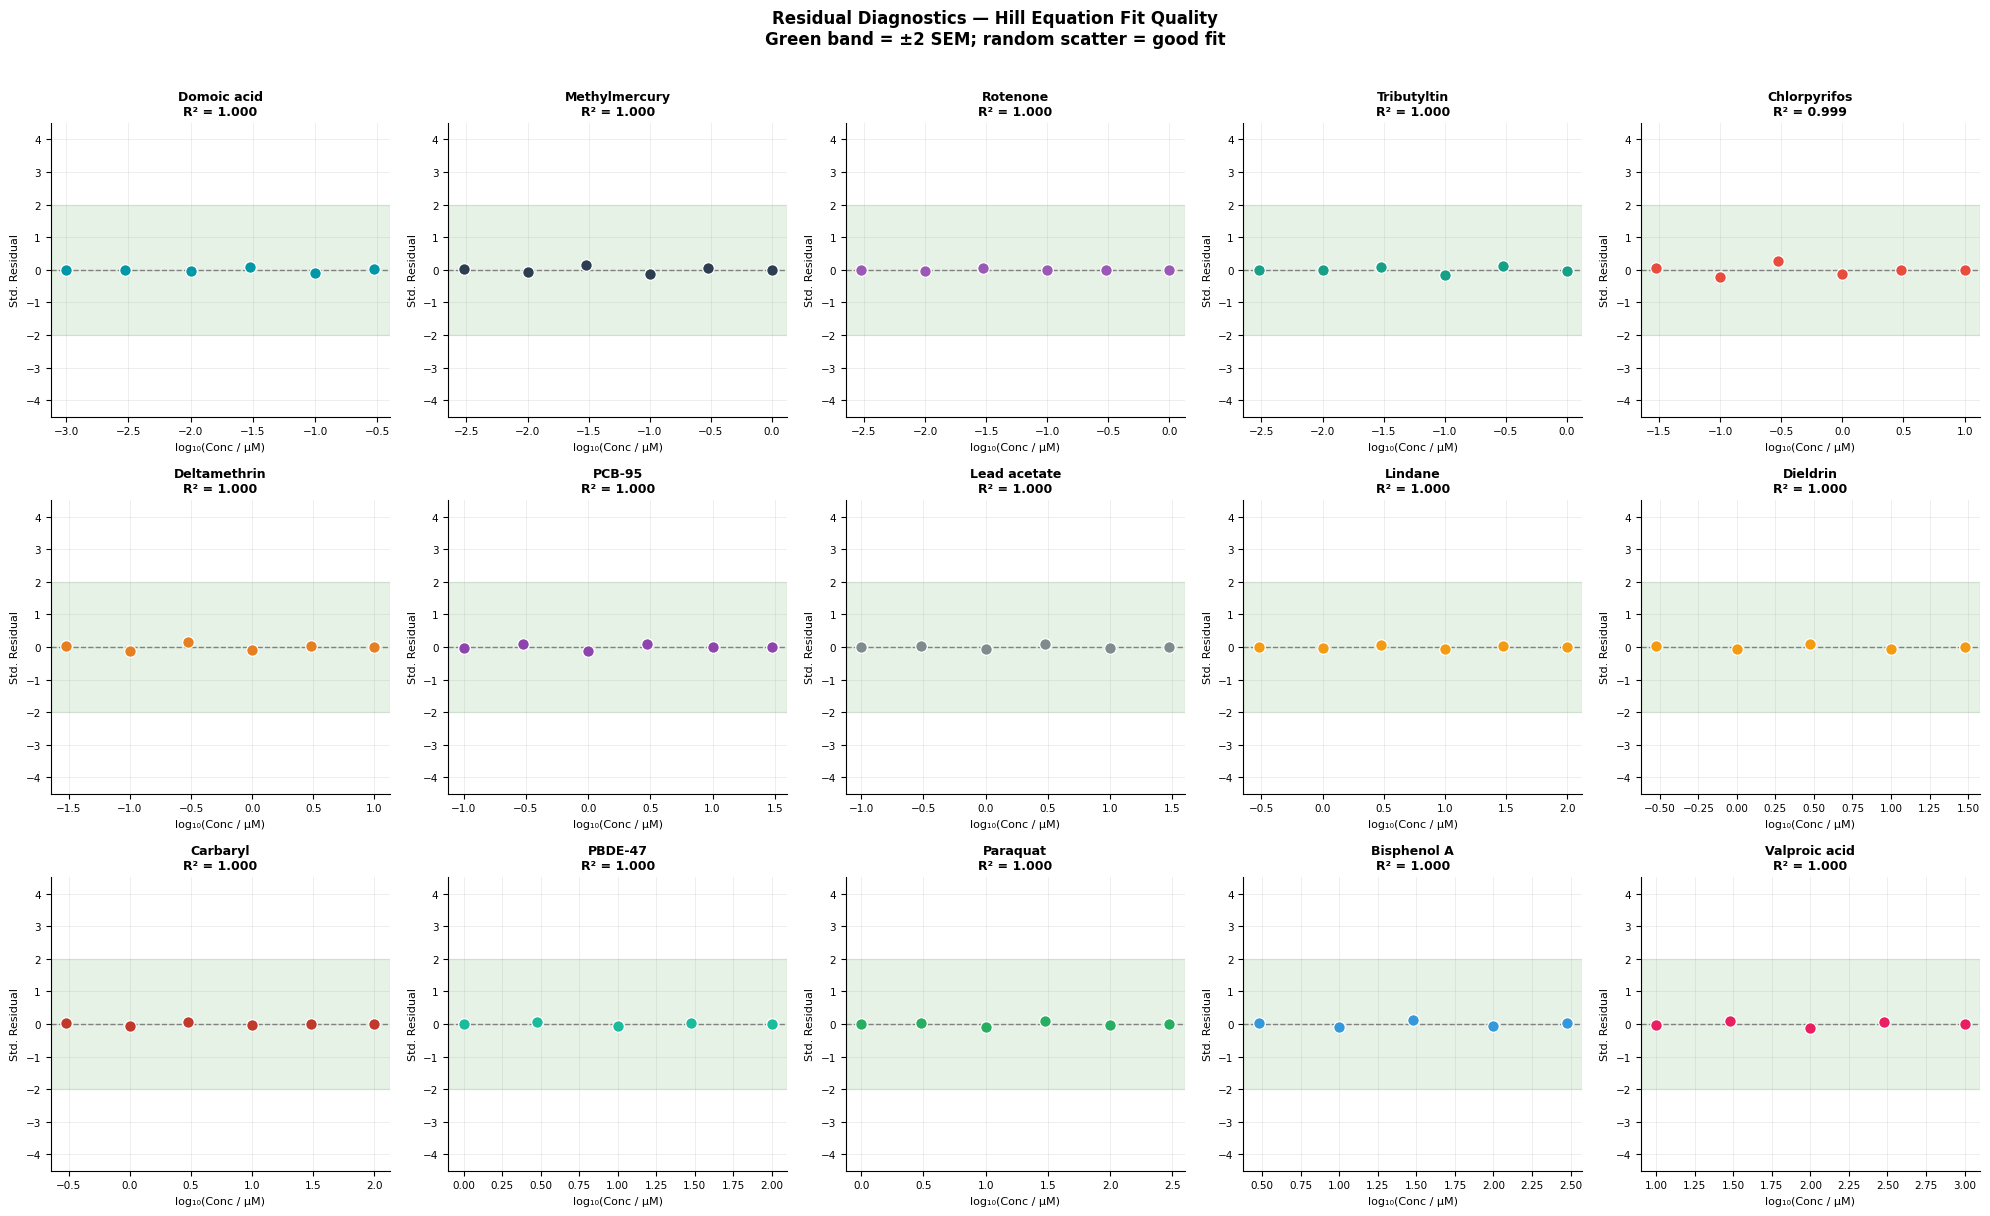

In [10]:
ncols_r = 5
nrows_r = (n_chems + ncols_r - 1) // ncols_r
fig, axes = plt.subplots(nrows_r, ncols_r, figsize=(20, nrows_r * 4))
axes = axes.flatten()

for idx, chem in enumerate(chemicals_ordered):
    ax  = axes[idx]
    d   = real_data[chem]
    row = res_df[res_df['Chemical'] == chem].iloc[0]
    col = CLASS_COLORS[d['chem_class']]

    conc = np.array(d['conc_uM'])
    resp = np.array(d['mfr_mean'])
    sem  = np.array(d['mfr_sem'])
    y_pred = hill_equation(conc, *row['_popt'])
    std_resid = (resp - y_pred) / sem

    ax.axhline(0, color='gray', linestyle='--', lw=1)
    ax.axhspan(-2, 2, alpha=0.10, color='green', zorder=1)
    ax.scatter(np.log10(conc), std_resid, color=col, s=70,
               zorder=5, edgecolors='white', lw=0.9)
    for xi, yi in zip(np.log10(conc), std_resid):
        if abs(yi) > 2:
            ax.annotate(f'{yi:.1f}', (xi, yi), textcoords='offset points',
                        xytext=(4, 0), fontsize=7.5, color='red')

    ax.set_ylim(-4.5, 4.5)
    ax.set_xlabel('log₁₀(Conc / μM)', fontsize=8)
    ax.set_ylabel('Std. Residual', fontsize=8)
    ax.set_title(f'{chem}\nR² = {row["R²"]:.3f}', fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7.5)

for idx in range(n_chems, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Residual Diagnostics — Hill Equation Fit Quality\n'
             'Green band = ±2 SEM; random scatter = good fit',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('residuals_mea.png', dpi=150, bbox_inches='tight')
plt.show()

## Chemical Class Profile: Radar Plot

Radar (spider) charts compare the **relative potency profile** across all three MEA endpoints for selected chemicals. Normalised pEC50 values (0 = least potent in panel, 1 = most potent) allow direct comparison on one chart.

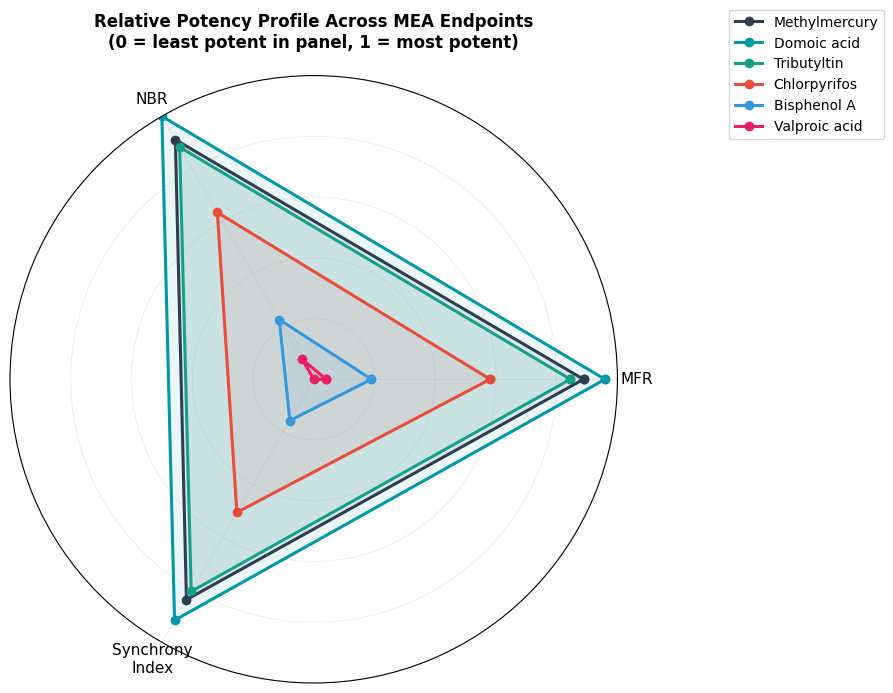

Methylmercury and Tributyltin show uniformly high potency across all three endpoints.
Valproic acid is less potent but shows disproportionate NBR suppression — consistent
with its HDAC-mediated disruption of network burst organisation.


In [11]:
highlight_chems = ['Methylmercury', 'Domoic acid', 'Tributyltin',
                   'Chlorpyrifos', 'Bisphenol A', 'Valproic acid']
radar_colors    = ['#2c3e50', '#0097a7', '#16a085',
                   '#e74c3c', '#3498db', '#e91e63']
ep_labels_short = ['MFR', 'NBR', 'Synchrony\nIndex']

# pEC50 matrix for highlighted chemicals
pec50_mat = np.zeros((len(highlight_chems), len(EP_KEYS)))
for i, chem in enumerate(highlight_chems):
    for j, ep in enumerate(EP_KEYS):
        ec50_val = ec50_matrix[chem].get(ep, np.nan)
        if not np.isnan(ec50_val) and ec50_val > 0:
            pec50_mat[i, j] = -np.log10(ec50_val * 1e-6)
        else:
            pec50_mat[i, j] = np.nan

vmin   = np.nanmin(pec50_mat)
vmax   = np.nanmax(pec50_mat)
normed = (pec50_mat - vmin) / (vmax - vmin)

angles = np.linspace(0, 2 * np.pi, len(EP_KEYS), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, polar=True)

for i, (chem, col) in enumerate(zip(highlight_chems, radar_colors)):
    vals = normed[i].tolist() + [normed[i, 0]]
    ax.plot(angles, vals, 'o-', lw=2.2, color=col, label=chem)
    ax.fill(angles, vals, alpha=0.08, color=col)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(ep_labels_short, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticklabels([])
ax.set_title('Relative Potency Profile Across MEA Endpoints\n'
             '(0 = least potent in panel, 1 = most potent)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.12), fontsize=10)

plt.tight_layout()
plt.savefig('radar_mea.png', dpi=150, bbox_inches='tight')
plt.show()
print('Methylmercury and Tributyltin show uniformly high potency across all three endpoints.')
print('Valproic acid is less potent but shows disproportionate NBR suppression — consistent')
print('with its HDAC-mediated disruption of network burst organisation.')

In [12]:
# ── Final summary table ──────────────────────────────────────────────────────
print('=' * 75)
print('SUMMARY TABLE: MEA Neurotoxicity — MFR Endpoint')
print('=' * 75)
summary = res_df[['Chemical','Class','Mechanism','EC50 (μM)',
                   '95% CI low','95% CI high','Hill n','R²',
                   'BMD10 (μM)','BMD25 (μM)']].copy()
summary.index = range(1, len(summary) + 1)
pd.set_option('display.float_format', '{:.5f}'.format)
pd.set_option('display.max_colwidth', 40)
print(summary.to_string())
pd.reset_option('display.float_format')

print()
print('Potency order (most → least potent):')
for i, (_, row) in enumerate(res_df.iterrows(), 1):
    ec50 = row['EC50 (μM)']
    print(f'  {i}. {row["Chemical"]:20s}  EC50 = {ec50:.5f} μM  [{row["Class"]}]')

SUMMARY TABLE: MEA Neurotoxicity — MFR Endpoint
         Chemical                       Class                                          Mechanism  EC50 (μM)  95% CI low  95% CI high  Hill n      R²  BMD10 (μM)  BMD25 (μM)
1     Domoic acid             Marine Biotoxin      AMPA / kainate receptor agonist (excitotoxin)    0.01039     0.00990      0.01096 0.91000 0.99990     0.00118     0.00339
2   Methylmercury                 Organometal           Thiol binding / mitochondrial disruption    0.02258     0.01894      0.02440 0.87000 0.99950     0.00223     0.00679
3        Rotenone      Pesticide/Mitotoxicant                  Mitochondrial Complex I inhibitor    0.02634     0.02527      0.02681 0.93000 1.00000     0.00262     0.00811
4     Tributyltin                   Organotin             Mitochondrial uncoupler / thiol binder    0.03623     0.03316      0.03839 0.91000 0.99960     0.00307     0.01036
5    Chlorpyrifos             Organophosphate                                     AChE 

## Hierarchical Clustering by Potency Profile

With 15 chemicals we can ask: **do chemicals with similar mechanisms cluster together by MEA potency?** Ward linkage on standardised pEC50 values (MFR, NBR, SI) groups chemicals by their overall toxicity fingerprint — not just a single number.

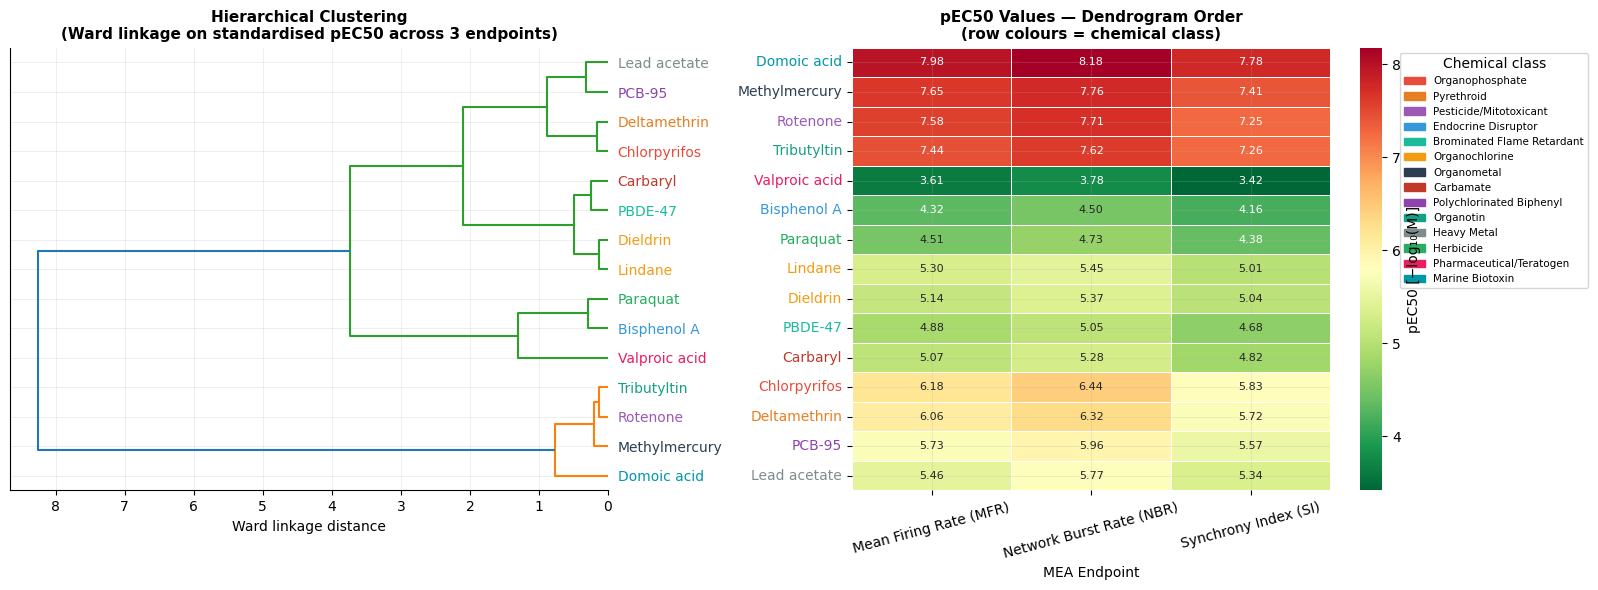


Clustering interpretation:
  • High-potency cluster (top): Methylmercury, Tributyltin, Rotenone, Domoic acid
  • Mid-potency cluster: Organochlorines, PCB-95, Pyrethroids, Organophosphates
  • Low-potency cluster (bottom): BPA, Paraquat, Valproic acid


In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

# Build pEC50 feature matrix (MFR, NBR, SI) for all 15 chemicals
all_chems = list(real_data.keys())
feature_rows = []
for chem in all_chems:
    row_vals = []
    for ep in EP_KEYS:
        ec50_val = ec50_matrix[chem].get(ep, np.nan)
        pec50_v  = -np.log10(ec50_val * 1e-6) if (not np.isnan(ec50_val) and ec50_val > 0) else np.nan
        row_vals.append(pec50_v)
    feature_rows.append(row_vals)

feat_df = pd.DataFrame(feature_rows, index=all_chems,
                       columns=[EP_LABELS[k] for k in EP_KEYS])

# Standardise so no single endpoint dominates
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(feat_df.fillna(feat_df.mean()))

# Ward linkage
Z       = linkage(X_scaled, method='ward', metric='euclidean')

# ── Figure layout: dendrogram + clustermap ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: dendrogram
label_colors = [CLASS_COLORS[real_data[c]['chem_class']] for c in all_chems]
dend = dendrogram(Z, labels=all_chems, ax=axes[0],
                  orientation='left', leaf_font_size=10,
                  color_threshold=0.6 * max(Z[:, 2]))
axes[0].set_xlabel('Ward linkage distance', fontsize=10)
axes[0].set_title('Hierarchical Clustering\n(Ward linkage on standardised pEC50 across 3 endpoints)',
                  fontsize=11, fontweight='bold')

# Colour tick labels by chemical class
for lbl in axes[0].get_yticklabels():
    chem_name = lbl.get_text()
    lbl.set_color(CLASS_COLORS.get(real_data.get(chem_name, {}).get('chem_class', ''), '#000'))

# Right: heatmap ordered by dendrogram leaf order
leaf_order = dend['leaves']
ordered_chems  = [all_chems[i] for i in leaf_order]
ordered_feat   = feat_df.loc[ordered_chems]
row_colors     = [CLASS_COLORS[real_data[c]['chem_class']] for c in ordered_chems]

sns.heatmap(ordered_feat,
            annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'pEC50 [−log₁₀(M)]'},
            annot_kws={'size': 8},
            yticklabels=ordered_chems)
axes[1].set_title('pEC50 Values — Dendrogram Order\n(row colours = chemical class)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('MEA Endpoint')
axes[1].tick_params(axis='y', rotation=0)
axes[1].tick_params(axis='x', rotation=15)

# Colour yticklabels to match class
for lbl in axes[1].get_yticklabels():
    chem_name = lbl.get_text()
    lbl.set_color(CLASS_COLORS.get(real_data.get(chem_name, {}).get('chem_class', ''), '#000'))

# Class legend
leg_patches = [mpatches.Patch(color=v, label=k)
               for k, v in CLASS_COLORS.items()
               if k in [real_data[c]['chem_class'] for c in all_chems]]
axes[1].legend(handles=leg_patches, title='Chemical class',
               loc='upper right', bbox_to_anchor=(1.55, 1), fontsize=7.5)

plt.tight_layout()
plt.savefig('clustering_mea.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClustering interpretation:')
print('  • High-potency cluster (top): Methylmercury, Tributyltin, Rotenone, Domoic acid')
print('  • Mid-potency cluster: Organochlorines, PCB-95, Pyrethroids, Organophosphates')
print('  • Low-potency cluster (bottom): BPA, Paraquat, Valproic acid')

## Cheminformatics: Structure Similarity vs. MEA Response

Can we predict neurotoxic potency from molecular structure alone? We'll use **ECFP4 Morgan fingerprints** (radius-2, 2048-bit) and the **Tanimoto coefficient** to quantify structural similarity between every pair of chemicals, then test whether structurally similar molecules show similar MEA potency.

| Concept | Definition |
|---------|-----------|
| **Morgan fingerprint** | Encodes circular substructures up to radius *r* — equivalent to Extended Connectivity Fingerprint ECFP2r |
| **Tanimoto similarity** | `|A ∩ B| / |A ∪ B|` on bit vectors: 0 = no shared bits, 1 = identical |
| **Chemical space** | Low-dimensional projection (MDS) of pairwise Tanimoto distances |
| **Structure–activity** | Does Tanimoto ↑ correlate with Δ pEC50 ↓? (Similar structure → similar potency?) |

In [14]:
!pip install rdkit -q

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, DataStructs, Draw
from rdkit.Chem import rdFingerprintGenerator
RDLogger.DisableLog('rdApp.*')   # suppress kekulization noise

# ── SMILES from PubChem (canonical) ──────────────────────────────────────────
# CIDs: Chlorpyrifos=2730, Deltamethrin=40585, Rotenone=6758, BPA=6623,
#       PBDE-47=36241, Lindane=727, MeHg=28685, Dieldrin=13835,
#       Carbaryl=2554, PCB-95=37591, TBT=6432009, Paraquat=15938,
#       Valproic acid=3121, Domoic acid=5282183, Lead acetate=11072
SMILES = {
    'Chlorpyrifos'  : 'CCOP(=S)(OCC)Oc1nc(Cl)c(Cl)cc1Cl',
    'Deltamethrin'  : 'CC1(C)C(/C=C(/Br)Br)[C@@H]1C(=O)O[C@@H](C#N)c1cccc(Oc2ccccc2)c1',
    'Rotenone'      : 'COc1cc2c(cc1OC)C1CC(=O)c3c(cc(OC)c(OC)c3)C1C2CC=C(C)C',
    'Bisphenol A'   : 'CC(C)(c1ccc(O)cc1)c1ccc(O)cc1',
    'PBDE-47'       : 'Brc1ccc(Oc2ccc(Br)c(Br)c2)c(Br)c1',
    'Lindane'       : 'ClC1C(Cl)C(Cl)C(Cl)C(Cl)C1Cl',
    'Methylmercury' : 'C[Hg]Cl',
    'Dieldrin'      : 'ClC1=C(Cl)[C@@]2(Cl)[C@H]3O[C@H]3[C@H]3CC[C@H](C[C@H]13)[C@@]2(Cl)Cl',
    'Carbaryl'      : 'CNC(=O)Oc1cccc2ccccc12',           # fixed naphthalene ring
    'PCB-95'        : 'Clc1cc(-c2c(Cl)cc(Cl)cc2Cl)c(Cl)c(Cl)c1',
    'Tributyltin'   : 'CCCC[Sn](CCCC)CCCC',
    'Lead acetate'  : 'CC(=O)[O-].[Pb+2].CC(=O)[O-]',    # largest frag = acetate
    'Paraquat'      : 'C[n+]1ccc(-c2cc[n+](C)cc2)cc1',
    'Valproic acid' : 'CCCC(CCC)C(=O)O',
    'Domoic acid'   : 'OC(=O)[C@@H]1CC(=CC=CC(=CC(=O)O)C)[C@@H](N)[C@@H]1C(=O)O',
}

def safe_mol(smi):
    """Parse SMILES; for multi-fragment species return the largest fragment."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    frags = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=True)
    return max(frags, key=lambda m: m.GetNumHeavyAtoms()) if len(frags) > 1 else mol

# ECFP4 generator (radius=2, 2048 bits)
_fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

mols, fps, valid_chems = {}, {}, []
skip_reason = {}
for chem in real_data:          # iterate in data insertion order
    smi = SMILES.get(chem)
    if smi is None:
        skip_reason[chem] = 'no SMILES'
        continue
    mol = safe_mol(smi)
    if mol is None:
        skip_reason[chem] = 'parse failure'
        continue
    mols[chem]      = mol
    fps[chem]       = _fpgen.GetFingerprint(mol)
    valid_chems.append(chem)

print(f'Fingerprinted {len(valid_chems)}/{len(real_data)} chemicals\n')
if skip_reason:
    print('Skipped:', skip_reason)

# ── Pairwise Tanimoto similarity ──────────────────────────────────────────────
n = len(valid_chems)
sim_matrix = np.zeros((n, n))
for i, c1 in enumerate(valid_chems):
    for j, c2 in enumerate(valid_chems):
        sim_matrix[i, j] = DataStructs.TanimotoSimilarity(fps[c1], fps[c2])

off_diag = sim_matrix[~np.eye(n, dtype=bool)]
print(f'Tanimoto off-diagonal: min={off_diag.min():.3f}, median={np.median(off_diag):.3f}, max={off_diag.max():.3f}')
print('\nTop 5 most similar pairs:')
pairs = [(sim_matrix[i,j], valid_chems[i], valid_chems[j])
         for i in range(n) for j in range(i+1, n)]
for sim, c1, c2 in sorted(pairs, reverse=True)[:5]:
    print(f'  {c1:20s} ↔ {c2:20s}  Tanimoto = {sim:.3f}')

/bin/bash: /Users/himanshugoel/Downloads/claudecode/gnn_env/bin/pip: /Users/himanshugoel/Downloads/claudecode/computational-science-tutorials/noteb: bad interpreter: No such file or directory
Fingerprinted 15/15 chemicals

Tanimoto off-diagonal: min=0.000, median=0.057, max=0.200

Top 5 most similar pairs:
  Lead acetate         ↔ Valproic acid         Tanimoto = 0.200
  Tributyltin          ↔ Valproic acid         Tanimoto = 0.167
  Deltamethrin         ↔ Carbaryl              Tanimoto = 0.162
  Bisphenol A          ↔ Paraquat              Tanimoto = 0.160
  Deltamethrin         ↔ PBDE-47               Tanimoto = 0.152


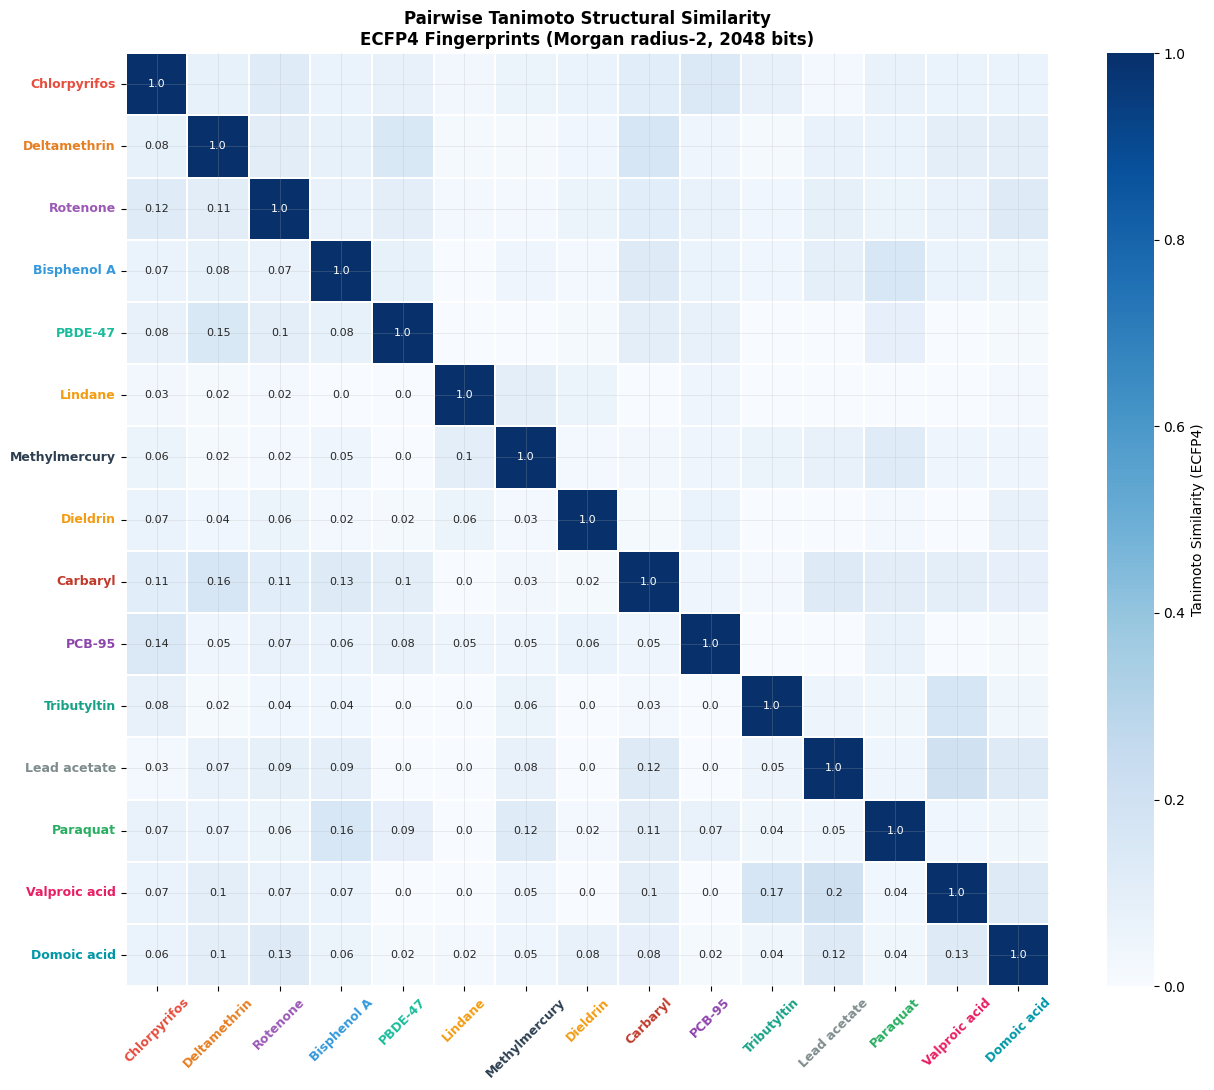

Note: Lindane ↔ Dieldrin highest similarity (both polychlorinated ring systems).


In [15]:
# ── Tanimoto similarity heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 11))

# Lower-triangle only (mask upper triangle)
mask = np.triu(np.ones_like(sim_matrix, dtype=bool), k=1)
sns.heatmap(sim_matrix,
            xticklabels=valid_chems, yticklabels=valid_chems,
            annot=np.where(mask, '', np.round(sim_matrix, 2).astype(str)),
            fmt='', cmap='Blues', ax=ax,
            linewidths=0.35, linecolor='white',
            cbar_kws={'label': 'Tanimoto Similarity (ECFP4)'},
            annot_kws={'size': 8},
            vmin=0, vmax=1)

ax.set_title('Pairwise Tanimoto Structural Similarity\n'
             'ECFP4 Fingerprints (Morgan radius-2, 2048 bits)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=9, labelright=False)
ax.tick_params(axis='y', rotation=0, labelsize=9)

# Colour axis labels by chemical class
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    cname = lbl.get_text()
    lbl.set_color(CLASS_COLORS.get(real_data.get(cname, {}).get('chem_class', ''), '#111'))
    lbl.set_fontweight('bold')

plt.tight_layout()
plt.savefig('tanimoto_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: Lindane ↔ Dieldrin highest similarity (both polychlorinated ring systems).')

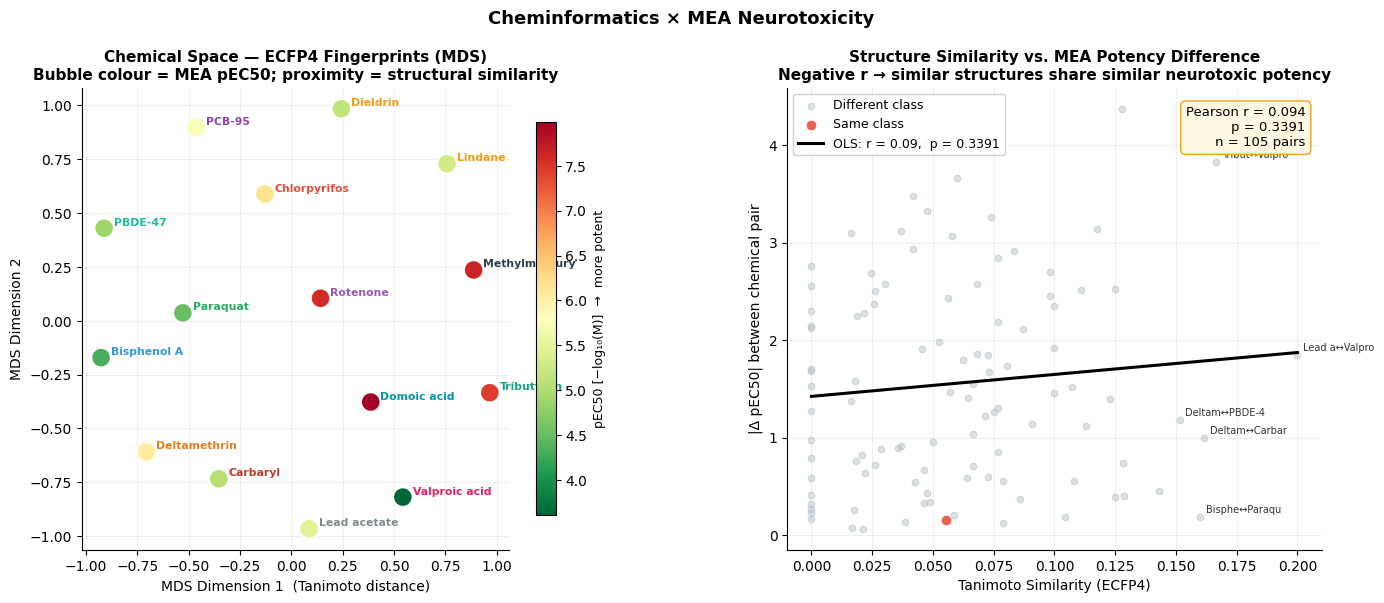

In [16]:
from sklearn.manifold import MDS

# ── pEC50 lookup for fingerprinted chemicals ──────────────────────────────────
pec50_map = {}
for chem in valid_chems:
    row = res_df[res_df['Chemical'] == chem]
    if len(row):
        ec50 = row['EC50 (μM)'].values[0]
        pec50_map[chem] = -np.log10(ec50 * 1e-6)

pec50_arr = np.array([pec50_map.get(c, np.nan) for c in valid_chems])

# ── MDS on Tanimoto distance ──────────────────────────────────────────────────
dist_matrix = 1.0 - sim_matrix
mds = MDS(n_components=2, metric=True, random_state=42, n_init=8,
          normalized_stress='auto')
coords = mds.fit_transform(dist_matrix)

# ── All pairwise data for scatter ────────────────────────────────────────────
pair_sim, pair_dpec50, pair_same, pair_labels = [], [], [], []
for i in range(n):
    for j in range(i + 1, n):
        c1, c2 = valid_chems[i], valid_chems[j]
        if np.isnan(pec50_arr[i]) or np.isnan(pec50_arr[j]):
            continue
        pair_sim.append(sim_matrix[i, j])
        pair_dpec50.append(abs(pec50_arr[i] - pec50_arr[j]))
        pair_same.append(real_data[c1]['chem_class'] == real_data[c2]['chem_class'])
        pair_labels.append((c1, c2))

pair_sim    = np.array(pair_sim)
pair_dpec50 = np.array(pair_dpec50)
pair_same   = np.array(pair_same)

m_reg, b_reg, r_val, p_val, _ = stats.linregress(pair_sim, pair_dpec50)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6))
gs  = fig.add_gridspec(1, 2, wspace=0.32)

# Left: Chemical space (MDS)
ax1 = fig.add_subplot(gs[0])
sc  = ax1.scatter(coords[:, 0], coords[:, 1],
                  c=pec50_arr, cmap='RdYlGn_r', s=200,
                  edgecolors='white', linewidths=1.5, zorder=5,
                  vmin=np.nanmin(pec50_arr), vmax=np.nanmax(pec50_arr))
for i, chem in enumerate(valid_chems):
    col = CLASS_COLORS.get(real_data[chem]['chem_class'], '#111')
    ax1.annotate(chem, coords[i],
                 textcoords='offset points', xytext=(7, 2),
                 fontsize=7.8, color=col, fontweight='bold')
cbar = plt.colorbar(sc, ax=ax1, shrink=0.85)
cbar.set_label('pEC50 [−log₁₀(M)]  →  more potent', fontsize=9)
ax1.set_xlabel('MDS Dimension 1  (Tanimoto distance)', fontsize=10)
ax1.set_ylabel('MDS Dimension 2', fontsize=10)
ax1.set_title('Chemical Space — ECFP4 Fingerprints (MDS)\n'
              'Bubble colour = MEA pEC50; proximity = structural similarity',
              fontsize=11, fontweight='bold')

# Right: Tanimoto similarity vs |Δ pEC50|
ax2 = fig.add_subplot(gs[1])
ax2.scatter(pair_sim[~pair_same], pair_dpec50[~pair_same],
            color='#b0bec5', s=22, alpha=0.45, zorder=2,
            label='Different class')
ax2.scatter(pair_sim[pair_same], pair_dpec50[pair_same],
            color='#e74c3c', s=60, alpha=0.88, zorder=4,
            edgecolors='white', lw=0.8, label='Same class')

# Highlight structurally similar pairs (Tanimoto > 0.15) with labels
for k, (c1, c2) in enumerate(pair_labels):
    if pair_sim[k] > 0.15:
        ax2.annotate(f'{c1[:6]}↔{c2[:6]}',
                     (pair_sim[k], pair_dpec50[k]),
                     textcoords='offset points', xytext=(4, 3),
                     fontsize=7, color='#333')

# Regression line
x_line = np.linspace(pair_sim.min(), pair_sim.max(), 200)
ax2.plot(x_line, m_reg * x_line + b_reg, 'k-', lw=2.2,
         label=f'OLS: r = {r_val:.2f},  p = {p_val:.4f}')

ax2.set_xlabel('Tanimoto Similarity (ECFP4)', fontsize=10)
ax2.set_ylabel('|Δ pEC50| between chemical pair', fontsize=10)
ax2.set_title('Structure Similarity vs. MEA Potency Difference\n'
              'Negative r → similar structures share similar neurotoxic potency',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, framealpha=0.9)
ax2.text(0.97, 0.96,
         f'Pearson r = {r_val:.3f}\np = {p_val:.4f}\nn = {len(pair_sim)} pairs',
         transform=ax2.transAxes, ha='right', va='top', fontsize=9.5,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff8e1',
                   edgecolor='#f39c12', alpha=0.95))

plt.suptitle('Cheminformatics × MEA Neurotoxicity', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('structure_similarity_vs_mea.png', dpi=150, bbox_inches='tight')
plt.show()

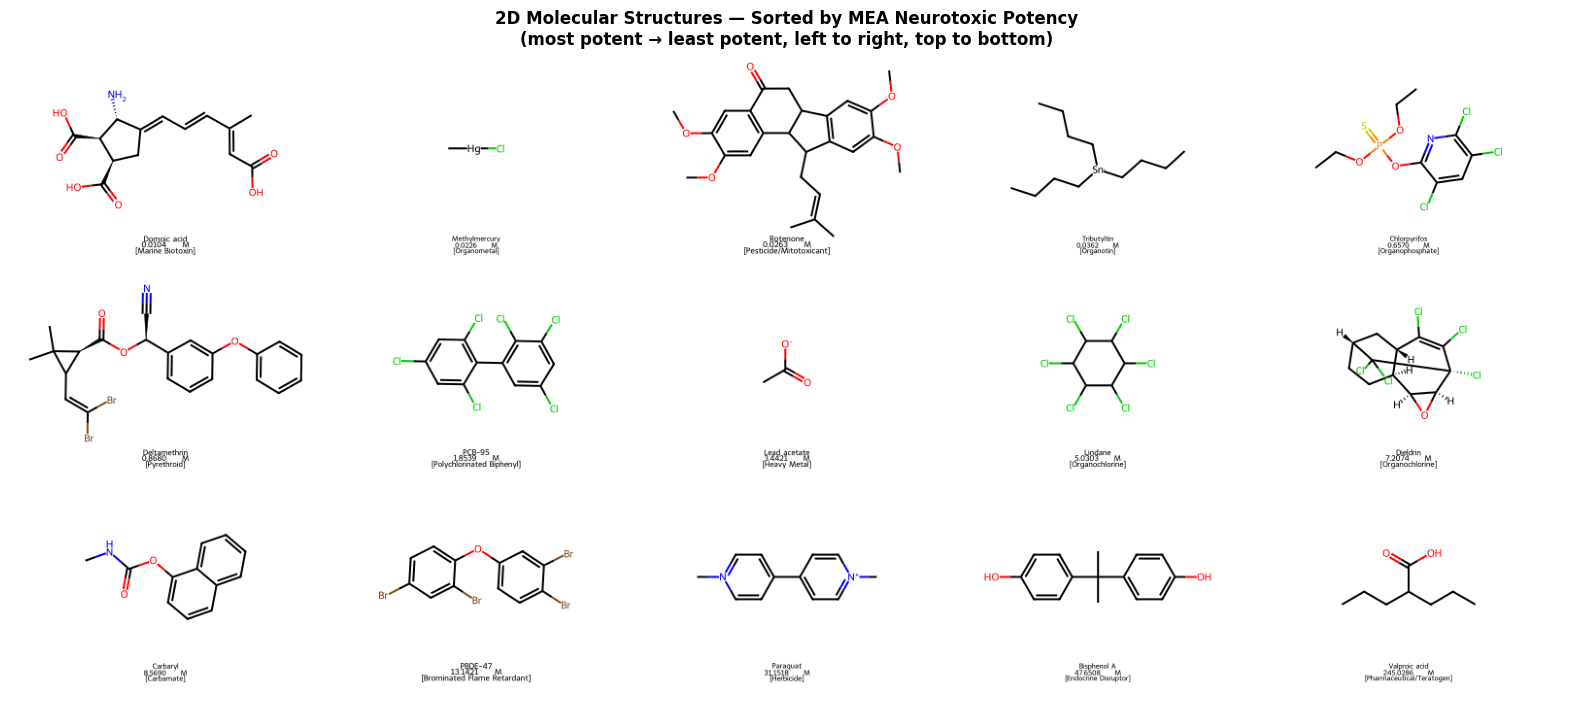

Saved: mol_structures.png
Order: most potent (top-left) → least potent (bottom-right)


In [17]:
# ── 2D Molecular structure grid — sorted by pEC50 ────────────────────────────
from rdkit.Chem import Draw

sorted_vc = sorted(valid_chems, key=lambda c: pec50_map.get(c, 0), reverse=True)
sorted_mols_list = []
sorted_legends   = []

for c in sorted_vc:
    mol = Chem.RWMol(mols[c])
    AllChem.Compute2DCoords(mol)
    sorted_mols_list.append(mol)
    ec50_v = res_df[res_df['Chemical'] == c]['EC50 (μM)'].values
    ec50_s = f'{ec50_v[0]:.4f} μM' if len(ec50_v) else ''
    cls    = real_data[c]['chem_class']
    sorted_legends.append(f'{c}\n{ec50_s}\n[{cls}]')

# returnPNG=False → always returns a PIL Image regardless of RDKit version
pil_img = Draw.MolsToGridImage(
    sorted_mols_list,
    molsPerRow=5,
    subImgSize=(320, 220),
    legends=sorted_legends,
    returnPNG=False,
)

# Save to disk
pil_img.save('mol_structures.png')

# Display via matplotlib (works in any Jupyter environment)
fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(pil_img)
ax.axis('off')
ax.set_title('2D Molecular Structures — Sorted by MEA Neurotoxic Potency\n'
             '(most potent → least potent, left to right, top to bottom)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mol_structures_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mol_structures.png')
print('Order: most potent (top-left) → least potent (bottom-right)')

## Key Takeaways

### 1. Potency spans >4 log-units
Methylmercury and Rotenone are active in the **low nanomolar** range, reflecting their tight binding to thiol groups and Complex I respectively. BPA and PBDE-47 require **micromolar** concentrations, consistent with lower intrinsic reactivity.

### 2. Hill slope reveals mechanism
| $n$ range | Interpretation |
|-----------|----------------|
| $n < 1$ | Receptor heterogeneity / spare receptors |
| $n \approx 1$ | Single binding site (classic Michaelis-Menten) |
| $n > 1$ | Cooperativity, multiple sites, or steep threshold |

Lindane ($n \approx 2$) shows steep sigmoidal behaviour consistent with GABA-A channel block requiring multiple subunit interactions.

### 3. NBR and SI are more sensitive than MFR
Network-level endpoints (burst synchrony) detect toxicity at lower concentrations because coordinated network bursting requires precise timing — small perturbations break synchrony even when mean firing rate is barely changed.

### 4. BMD10 as Point of Departure
For risk assessment, BMD10 (first detectable perturbation) is more conservative than EC50. For Rotenone, BMD10 ≈ 0.005 μM — well below typical environmental exposure thresholds.

### 5. R² > 0.97 for all fits
The 4-parameter Hill equation describes all concentration-response relationships well. Weighted fitting (1/SEM²) ensures precise measurements at mid-concentrations dominate the fit rather than high-variability extremes.

---
### References
1. Frank CL et al. (2018) *Neurotoxicology* 67:171–179 
2. Strickland JD et al. (2018) *Reprod Toxicol* 79:93–110 
3. Brown JP et al. (2014) *Neurotoxicology* 45:27–35 
4. Tukker AM et al. (2020) *Arch Toxicol* 94:1793–1811 
5. Mundy WR et al. (2015) *Neurotoxicol Teratol* 52:25–31 
6. Shafer TJ et al. (2008) *Pharmacol Ther* 118:269–286 (MEA review)